# Selección del mejor modelo de Machine Learning
## Dataset `corazon.csv` — predicción de enfermedad cardíaca

---

### Objetivo

Encontrar el modelo que resuelva mejor el problema y **demostrar que supera al
modelo base** construido en la tarea anterior. No basta con que tenga un número más
alto: hay que probar que la diferencia no es ruido de partición.

### Punto de partida heredado de las dos tareas previas

| Elemento | Valor establecido |
|---|---|
| Pipeline de preprocesamiento | 9 ramas por tipo de dato, 13 atributos → 50 |
| Partición | 80/20 estratificada, `random_state=42` (idéntica en las tres tareas) |
| Métrica principal | **F1**, con la **sensibilidad** como restricción clínica |
| Modelo base oficial | Heurística `thal != normal` → F1 ≈ 0.733 |
| Listón exigente | Heurística clínica de 4 reglas → **F1 ≈ 0.80** |

El listón real es el segundo. Un modelo que no supere las cuatro reglas escritas a
mano no justifica su existencia.

### Metodología

```
12 modelos (6 familias)
      ↓  cribado rápido con validación cruzada 5-fold
      ↓  se eliminan los que están por debajo del promedio
modelos supervivientes
      ↓  validación cruzada repetida 10×3, múltiples métricas
3 mejores modelos
      ↓  optimización de hiperparámetros (ronda 1)
      ↓  DIAGNÓSTICO: ¿sobreajuste?  →  ronda 2 con espacios regularizados
finalistas
      ↓  comparación con pruebas estadísticas pareadas
modelo ganador
      ↓  comparación estadística contra el modelo base
      ↓  entrenamiento final, evaluación en test, curvas, persistencia
```

### Contenido

| Sección | Contenido |
|---|---|
| 1–2 | Pipeline reutilizado y partición Train/Test |
| 3 | Métricas y línea base heredada |
| 4 | Catálogo de 12 modelos de 6 familias distintas |
| 5 | Cribado inicial y eliminación de los modelos por debajo del promedio |
| 6 | Validación cruzada repetida de los supervivientes |
| 7 | Optimización de hiperparámetros — ronda 1 |
| 8 | Diagnóstico de sobreajuste y **ronda 2 con espacios regularizados** |
| 9 | **Comparación con pruebas estadísticas** y selección del ganador |
| 10 | Comparación estadística contra el modelo base |
| 11 | Entrenamiento final y evaluación en el conjunto de prueba |
| 12 | Diagnóstico de *underfitting* / *overfitting* |
| 13 | Ajuste del umbral de decisión |
| 14 | Curvas de aprendizaje y escalabilidad |
| 15 | Importancia de atributos |
| 16 | Persistencia del pipeline + modelo |
| 17–19 | Interpretación, análisis y recomendaciones |

In [1]:
import time
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy import stats
from scipy.stats import loguniform, randint, uniform
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
UMBRAL_DEFECTO = 0.5
NIVEL_SIGNIFICACION = 0.05
PRECISION_MINIMA = 0.75

AZUL, NARANJA, AQUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, VERDE, VIOLETA, ROJO = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
TINTA, TINTA2, GRIS = "#0b0b0b", "#52514e", "#c9c8c2"
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d8d7d2",
        "axes.grid": True,
        "grid.color": "#ebeae5",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": TINTA,
        "axes.labelcolor": TINTA2,
        "xtick.color": TINTA2,
        "ytick.color": TINTA2,
        "axes.titlesize": 11,
        "font.size": 9,
        "figure.dpi": 110,
    }
)

print("scikit-learn:", sklearn.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

scikit-learn: 1.8.0 | pandas: 3.0.2 | numpy: 2.4.4


---
# 1. Pipeline de preprocesamiento reutilizado

Idéntico al de las dos tareas anteriores. **Es la condición que hace válida toda la
comparación**: si el preprocesamiento cambiara, no se sabría si una mejora viene del
modelo o de haber preparado mejor los datos.

Un único cambio, y es de reproducibilidad: `mutual_info_classif` se envuelve en una
función con `random_state` fijo. Sin él, la selección de atributos daría un ranking
ligeramente distinto en cada ejecución y los resultados no serían reproducibles.

In [2]:
# ---------------------------------------------------------------- catálogo del dominio
CATEGORIAS_VALIDAS = {
    "sex": ["female", "male"],
    "chest_pain": ["asymptomatic", "nonanginal", "nontypical", "typical"],
    "rest_ecg": ["left ventricular hypertrophy", "normal", "st-t wave abnormality"],
    "exang": ["0", "1"],
    "slope": ["1", "2", "3"],
    "thal": ["fixed", "normal", "reversable"],
    "disease": ["0", "1"],
}
COLS_NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca", "fbs"]
OBJETIVO = "disease"


def sanear_dataset(df):
    """Convierte tipos y transforma en NaN todo valor no interpretable."""
    df = df.copy()
    for col in COLS_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for col, validas in CATEGORIAS_VALIDAS.items():
        s = df[col].astype("string").str.strip().str.lower()
        s = s.str.replace(r"\s+", " ", regex=True)
        df[col] = s.where(s.isin(validas), other=pd.NA)
    return df


def a_numerico(X):
    """Convierte todas las columnas a float; lo no convertible queda como NaN."""
    return pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)


def a_texto(X):
    """Convierte a texto normalizado usando np.nan para los faltantes."""
    df = pd.DataFrame(X).astype(object)

    def normalizar(valor):
        return np.nan if pd.isna(valor) else str(valor).strip().lower()

    aplicar = df.map if hasattr(pd.DataFrame, "map") else df.applymap
    return aplicar(normalizar)


def nombres_log(transformador, nombres):
    """Nombres de salida de la rama logarítmica."""
    return np.array([f"log_{n}" for n in nombres])


def nombres_raiz(transformador, nombres):
    """Nombres de salida de la rama de raíz cuadrada."""
    return np.array([f"sqrt_{n}" for n in nombres])


A_NUMERICO = FunctionTransformer(a_numerico, feature_names_out="one-to-one")
A_TEXTO = FunctionTransformer(a_texto, feature_names_out="one-to-one")

In [3]:
class SaneadorTipos(TransformerMixin, BaseEstimator):
    """Convierte a numérico o a categoría válida, marcando como NaN lo no interpretable."""

    def __init__(self, cols_numericas=None, categorias_validas=None):
        self.cols_numericas = cols_numericas
        self.categorias_validas = categorias_validas

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols_numericas or []:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
        for col, validas in (self.categorias_validas or {}).items():
            if col in X.columns:
                s = X[col].astype("string").str.strip().str.lower()
                s = s.str.replace(r"\s+", " ", regex=True)
                X[col] = s.where(s.isin(validas), other=pd.NA)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_ if input_features is None else input_features)


class RecortadorAtipicos(TransformerMixin, BaseEstimator):
    """Winsoriza cada columna numérica a los límites de Tukey aprendidos en fit."""

    def __init__(self, factor=1.5, metodo="iqr"):
        self.factor = factor
        self.metodo = metodo

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.nombres_entrada_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        Xn = X.apply(pd.to_numeric, errors="coerce").astype(float)
        if self.metodo == "iqr":
            q1, q3 = Xn.quantile(0.25), Xn.quantile(0.75)
            iqr = q3 - q1
            self.limite_inferior_ = (q1 - self.factor * iqr).to_numpy(dtype=float)
            self.limite_superior_ = (q3 + self.factor * iqr).to_numpy(dtype=float)
        else:
            self.limite_inferior_ = Xn.quantile(0.01).to_numpy(dtype=float)
            self.limite_superior_ = Xn.quantile(0.99).to_numpy(dtype=float)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)
        return X.clip(lower=self.limite_inferior_, upper=self.limite_superior_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.nombres_entrada_ if input_features is None else input_features)


class AtributosClinicos(TransformerMixin, BaseEstimator):
    """Genera atributos derivados a partir del conocimiento del dominio clínico."""

    def __init__(self, incluir_interacciones=True):
        self.incluir_interacciones = incluir_interacciones

    def fit(self, X, y=None):
        self.nombres_entrada_ = np.asarray(pd.DataFrame(X).columns)
        self.n_features_in_ = len(self.nombres_entrada_)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        def num(columna):
            """Devuelve una columna convertida a número."""
            return pd.to_numeric(X[columna], errors="coerce")

        edad, fc_max = num("age"), num("max_hr")
        fc_teorica = 220 - edad

        nuevas = pd.DataFrame(index=X.index)
        nuevas["fc_maxima_teorica"] = fc_teorica
        nuevas["reserva_cardiaca"] = fc_max - fc_teorica
        nuevas["pct_fc_alcanzada"] = fc_max / fc_teorica.replace(0, np.nan)

        if self.incluir_interacciones:
            nuevas["ratio_chol_edad"] = num("chol") / edad.replace(0, np.nan)
            nuevas["presion_x_chol"] = num("rest_bp") * num("chol") / 1000.0
            nuevas["indice_riesgo_st"] = num("old_peak") * (num("slope") - 1)

        return nuevas.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        base = ["fc_maxima_teorica", "reserva_cardiaca", "pct_fc_alcanzada"]
        if self.incluir_interacciones:
            base += ["ratio_chol_edad", "presion_x_chol", "indice_riesgo_st"]
        return np.asarray(base)

In [4]:
def informacion_mutua(X, y):
    """Información mutua con semilla fija, para que la selección sea reproducible."""
    return mutual_info_classif(X, y, random_state=RANDOM_STATE)


# ---------------------------------------------------------------- grupos de columnas
CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
ASIMETRICAS = ["chol", "old_peak"]
DISCRETIZAR = ["age", "chol", "max_hr"]
CONTEO = ["ca"]
BINARIAS = ["sex", "exang", "fbs"]
ORDINALES = ["slope"]
NOMINALES = ["chest_pain", "rest_ecg", "thal"]
DERIVADAS_IN = ["age", "max_hr", "chol", "rest_bp", "old_peak", "slope"]


def construir_preprocesador():
    """Devuelve el ColumnTransformer con una rama por tipo de dato."""
    rama_continuas = Pipeline(
        [
            ("atipicos", RecortadorAtipicos(factor=1.5, metodo="iqr")),
            ("imputador", SimpleImputer(strategy="median", add_indicator=True)),
            ("potencia", PowerTransformer(method="yeo-johnson", standardize=False)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_log = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, validate=True, feature_names_out=nombres_log)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_raiz = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("raiz", FunctionTransformer(np.sqrt, validate=True, feature_names_out=nombres_raiz)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_discretizacion = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("intervalos", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile")),
        ]
    )
    rama_derivadas = Pipeline(
        [
            ("generador", AtributosClinicos(incluir_interacciones=True)),
            ("imputador", SimpleImputer(strategy="median")),
            ("atipicos", RecortadorAtipicos(factor=3.0, metodo="iqr")),
            ("escalador", StandardScaler()),
        ]
    )
    rama_conteo = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_binarias = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]
    )
    rama_ordinales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OrdinalEncoder(
                    categories=[["1", "2", "3"]],
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_nominales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("continuas", rama_continuas, CONTINUAS),
            ("log", rama_log, ASIMETRICAS),
            ("raiz", rama_raiz, ASIMETRICAS),
            ("discretas", rama_discretizacion, DISCRETIZAR),
            ("derivadas", rama_derivadas, DERIVADAS_IN),
            ("conteo", rama_conteo, CONTEO),
            ("binarias", rama_binarias, BINARIAS),
            ("ordinales", rama_ordinales, ORDINALES),
            ("nominales", rama_nominales, NOMINALES),
        ],
        remainder="drop",
    )


def construir_pipeline(modelo):
    """Pipeline completo: saneamiento + preprocesamiento + selección + estimador."""
    return Pipeline(
        [
            ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
            ("preproceso", construir_preprocesador()),
            (
                "seleccion",
                Pipeline(
                    [
                        ("umbral_varianza", VarianceThreshold(threshold=0.0)),
                        ("mejores_k", SelectKBest(score_func=informacion_mutua, k="all")),
                    ]
                ),
            ),
            ("modelo", modelo),
        ]
    )

---
# 2. Carga de datos y división Train / Test

Misma semilla y misma estratificación que en las tareas anteriores: el conjunto de
prueba contiene exactamente los mismos 96 pacientes, y por tanto los números son
directamente comparables con los del modelo base.

In [5]:
crudo = pd.read_csv("corazon.csv", dtype=str)

limpio = sanear_dataset(crudo).drop_duplicates().reset_index(drop=True)
limpio = limpio.dropna(subset=[OBJETIVO]).reset_index(drop=True)
limpio[OBJETIVO] = limpio[OBJETIVO].astype(int)
limpio = limpio.drop_duplicates().reset_index(drop=True)

X = limpio.drop(columns=[OBJETIVO])
y = limpio[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Dataset saneado : {limpio.shape[0]} filas, {X.shape[1]} atributos")
print(f"X_train         : {X_train.shape}   positivos: {y_train.mean():.1%}")
print(f"X_test          : {X_test.shape}   positivos: {y_test.mean():.1%}")

Dataset saneado : 480 filas, 13 atributos
X_train         : (384, 13)   positivos: 47.9%
X_test          : (96, 13)   positivos: 47.9%


---
# 3. Métricas y línea base heredada

Las métricas y su justificación clínica se fijaron en la tarea del modelo base y
**no se cambian aquí**. Cambiar la métrica después de ver los resultados es una de
las formas más habituales de engañarse a uno mismo.

* **Métrica principal de decisión: F1.** Equilibra los dos errores en un problema
  con clases balanceadas.
* **Restricción clínica: sensibilidad.** El falso negativo (un enfermo que se va sin
  diagnóstico) es mucho más caro que el falso positivo.
* **Métricas de control:** ROC AUC y PR AUC (independientes del umbral),
  exactitud balanceada y precisión.

In [6]:
METRICAS = [
    "f1",
    "recall",
    "precision",
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
    "accuracy",
]
NOMBRES_METRICAS = {
    "f1": "F1",
    "recall": "sensibilidad",
    "precision": "precisión",
    "roc_auc": "ROC AUC",
    "average_precision": "PR AUC",
    "balanced_accuracy": "exactitud balanceada",
    "accuracy": "exactitud",
}
METRICA_PRINCIPAL = "f1"


class HeuristicaClinica(ClassifierMixin, BaseEstimator):
    """Modelo base de la tarea anterior: cuenta 4 señales clínicas de riesgo."""

    SENALES = 4

    def __init__(self, minimo_senales=2):
        self.minimo_senales = minimo_senales

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = pd.DataFrame(X).shape[1]
        return self

    def _contar_senales(self, X):
        """Suma las condiciones de riesgo presentes en cada paciente."""
        X = pd.DataFrame(X)
        texto = a_texto(X[["thal", "chest_pain"]])
        vasos = pd.to_numeric(X["ca"], errors="coerce").fillna(0)
        angina = pd.to_numeric(X["exang"], errors="coerce").fillna(0)
        return (
            (texto["thal"].notna() & (texto["thal"] != "normal")).astype(int)
            + (texto["chest_pain"] == "asymptomatic").astype(int)
            + (vasos >= 1).astype(int)
            + (angina == 1).astype(int)
        ).to_numpy(dtype=float)

    def predict(self, X):
        return (self._contar_senales(X) >= self.minimo_senales).astype(int)

    def predict_proba(self, X):
        p = self._contar_senales(X) / self.SENALES
        return np.column_stack([1 - p, p])


MODELO_BASE = Pipeline(
    [
        ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
        ("modelo", HeuristicaClinica(minimo_senales=2)),
    ]
)

cv_rapida = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_base = cross_val_score(MODELO_BASE, X_train, y_train, cv=cv_rapida, scoring="f1")

print(
    f"Modelo base heredado (heurística de 4 reglas): F1 = {f1_base.mean():.4f} ± {f1_base.std():.4f}"
)
print("\nEste es el número que el modelo ganador tendrá que superar de forma demostrable.")

Modelo base heredado (heurística de 4 reglas): F1 = 0.8005 ± 0.0444

Este es el número que el modelo ganador tendrá que superar de forma demostrable.


---
# 4. Catálogo de modelos candidatos

Se seleccionan **12 modelos de 7 familias con supuestos matemáticos distintos**. La
diversidad es deliberada: familias que fallan por razones distintas exploran el
problema desde ángulos distintos, mientras que probar diez variantes de árboles solo
mide una misma hipótesis diez veces.

| Familia | Modelos | Supuesto sobre los datos | Por qué se incluye |
|---|---|---|---|
| **Lineales** | Regresión logística, LDA | La frontera entre clases es (casi) un hiperplano | Interpretables, robustos con pocos datos, estándar en la literatura médica |
| **Basados en distancias** | k-NN, SVM RBF | Pacientes parecidos tienen diagnósticos parecidos | Capturan fronteras no lineales; se benefician del escalado del pipeline |
| **Probabilísticos** | Naive Bayes gaussiano | Los atributos son condicionalmente independientes | Muy rápido y sorprendentemente competente como referencia |
| **Árboles individuales** | Árbol de decisión | Reglas jerárquicas de umbrales | Máxima interpretabilidad; alta varianza |
| **Ensambles por *bagging*** | Random Forest, Extra Trees | Promediar árboles decorrelacionados reduce la varianza | Robustos, poco sensibles a hiperparámetros |
| **Ensambles por *boosting*** | Gradient Boosting, HistGB, AdaBoost | Corregir secuencialmente los errores del modelo anterior | Suelen ganar en datos tabulares |
| **Redes neuronales** | MLP | Composición de transformaciones no lineales | Referencia de un modelo de alta capacidad |

**Todos se envuelven en el mismo pipeline de preprocesamiento**, de modo que la
comparación aísla la contribución del algoritmo.

In [7]:
CANDIDATOS = {
    "Regresión logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Análisis discriminante lineal": LinearDiscriminantAnalysis(),
    "k vecinos más cercanos": KNeighborsClassifier(),
    "SVM (kernel RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes gaussiano": GaussianNB(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Red neuronal (MLP)": MLPClassifier(
        hidden_layer_sizes=(32, 16), max_iter=1500, random_state=RANDOM_STATE
    ),
}

FAMILIAS = {
    "Regresión logística": "lineal",
    "Análisis discriminante lineal": "lineal",
    "k vecinos más cercanos": "distancias",
    "SVM (kernel RBF)": "distancias",
    "Naive Bayes gaussiano": "probabilístico",
    "Árbol de decisión": "árbol",
    "Random Forest": "bagging",
    "Extra Trees": "bagging",
    "Gradient Boosting": "boosting",
    "HistGradientBoosting": "boosting",
    "AdaBoost": "boosting",
    "Red neuronal (MLP)": "red neuronal",
}

print(f"{len(CANDIDATOS)} modelos candidatos de {len(set(FAMILIAS.values()))} familias distintas")

12 modelos candidatos de 7 familias distintas


---
# 5. Cribado inicial y eliminación de los modelos por debajo del promedio

Primera pasada barata: validación cruzada estratificada de 5 particiones sobre la
métrica principal. El objetivo no es medir con precisión, sino **descartar rápido**
para poder invertir el presupuesto de cómputo en los candidatos serios.

**Criterio de eliminación:** se descarta todo modelo cuyo F1 medio esté por debajo
del promedio de los 12 modelos.

In [8]:
filas_cribado = []
for nombre, modelo in CANDIDATOS.items():
    inicio = time.perf_counter()
    scores = cross_val_score(
        construir_pipeline(modelo),
        X_train,
        y_train,
        cv=cv_rapida,
        scoring=METRICA_PRINCIPAL,
        n_jobs=-1,
    )
    filas_cribado.append(
        {
            "modelo": nombre,
            "familia": FAMILIAS[nombre],
            "f1_medio": scores.mean(),
            "f1_std": scores.std(),
            "segundos": time.perf_counter() - inicio,
        }
    )

cribado = (
    pd.DataFrame(filas_cribado).sort_values("f1_medio", ascending=False).reset_index(drop=True)
)
PROMEDIO_CRIBADO = cribado["f1_medio"].mean()
cribado["supera_promedio"] = cribado["f1_medio"] >= PROMEDIO_CRIBADO

print(f"Promedio de F1 de los {len(cribado)} modelos: {PROMEDIO_CRIBADO:.4f}\n")
cribado.round(4)

Promedio de F1 de los 12 modelos: 0.7877



,modelo,familia,f1_medio,f1_std,segundos,supera_promedio
0,AdaBoost,boosting,0.8287,0.0328,1.4481,True
1,HistGradientBoosting,boosting,0.8227,0.0639,1.5065,True
2,Gradient Boosting,boosting,0.8209,0.0570,1.7146,True
3,Random Forest,bagging,0.8137,0.0621,2.7881,True
4,Regresión logística,lineal,0.8061,0.0351,3.1291,True
5,Extra Trees,bagging,0.7951,0.0719,2.4049,True
6,Análisis discriminante lineal,lineal,0.7801,0.0508,1.1347,False
7,Red neuronal (MLP),red neuronal,0.7796,0.0505,2.5757,False
8,Naive Bayes gaussiano,probabilístico,0.7743,0.0696,1.1156,False
9,SVM (kernel RBF),distancias,0.7714,0.0810,1.2898,False


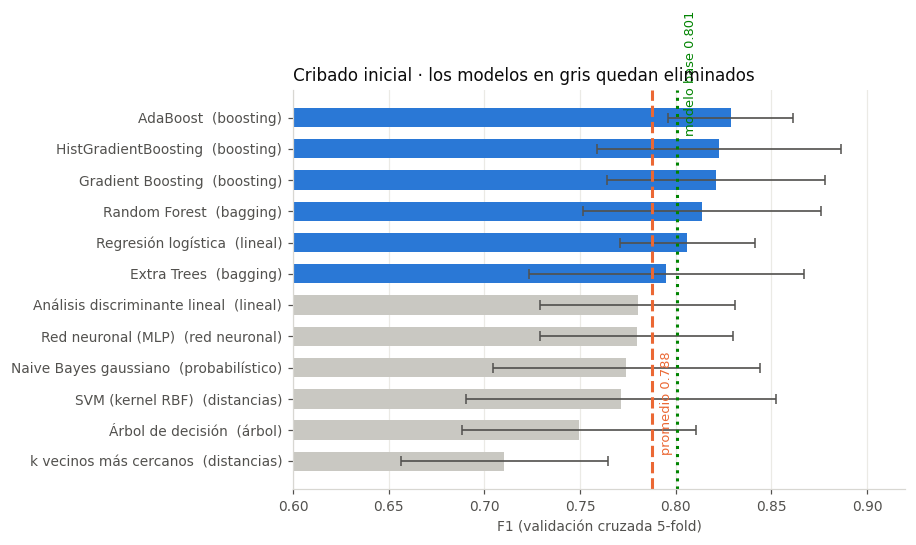

In [9]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))

orden = cribado.sort_values("f1_medio")
colores = [AZUL if supera else GRIS for supera in orden["supera_promedio"]]
posiciones = np.arange(len(orden))

ax.barh(
    posiciones,
    orden["f1_medio"],
    xerr=orden["f1_std"],
    color=colores,
    height=0.62,
    error_kw={"ecolor": TINTA2, "elinewidth": 1.1, "capsize": 3},
)
ax.axvline(PROMEDIO_CRIBADO, color=NARANJA, linestyle="--", linewidth=2)
ax.text(
    PROMEDIO_CRIBADO + 0.004,
    0.2,
    f"promedio {PROMEDIO_CRIBADO:.3f}",
    fontsize=8.5,
    color=NARANJA,
    rotation=90,
    va="bottom",
)
ax.axvline(f1_base.mean(), color=VERDE, linestyle=":", linewidth=2)
ax.text(
    f1_base.mean() + 0.004,
    len(orden) - 1.6,
    f"modelo base {f1_base.mean():.3f}",
    fontsize=8.5,
    color=VERDE,
    rotation=90,
    va="bottom",
)

ax.set_yticks(posiciones)
ax.set_yticklabels([f"{m}  ({f})" for m, f in zip(orden["modelo"], orden["familia"], strict=True)])
ax.set_xlim(0.6, 0.92)
ax.set_xlabel("F1 (validación cruzada 5-fold)")
ax.set_title("Cribado inicial · los modelos en gris quedan eliminados", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [10]:
SUPERVIVIENTES = cribado.loc[cribado["supera_promedio"], "modelo"].tolist()
ELIMINADOS = cribado.loc[~cribado["supera_promedio"], "modelo"].tolist()

print(f"SUPERVIVEN ({len(SUPERVIVIENTES)}):")
for nombre in SUPERVIVIENTES:
    print(f"   {nombre:<32} F1 = {cribado.set_index('modelo').loc[nombre, 'f1_medio']:.4f}")
print(f"\nELIMINADOS ({len(ELIMINADOS)}):")
for nombre in ELIMINADOS:
    print(f"   {nombre:<32} F1 = {cribado.set_index('modelo').loc[nombre, 'f1_medio']:.4f}")

print("\nFamilias que sobreviven:", sorted({FAMILIAS[n] for n in SUPERVIVIENTES}))

SUPERVIVEN (6):
   AdaBoost                         F1 = 0.8287
   HistGradientBoosting             F1 = 0.8227
   Gradient Boosting                F1 = 0.8209
   Random Forest                    F1 = 0.8137
   Regresión logística              F1 = 0.8061
   Extra Trees                      F1 = 0.7951

ELIMINADOS (6):
   Análisis discriminante lineal    F1 = 0.7801
   Red neuronal (MLP)               F1 = 0.7796
   Naive Bayes gaussiano            F1 = 0.7743
   SVM (kernel RBF)                 F1 = 0.7714
   Árbol de decisión                F1 = 0.7497
   k vecinos más cercanos           F1 = 0.7103

Familias que sobreviven: ['bagging', 'boosting', 'lineal']


---
# 6. Validación cruzada repetida de los supervivientes

El cribado usó 5 particiones: suficiente para descartar, insuficiente para decidir.
Los supervivientes se reevalúan con **`RepeatedStratifiedKFold` de 10 particiones
repetidas 3 veces = 30 estimaciones por modelo** y sobre todas las métricas.

Repetir con particiones distintas reduce la varianza de la estimación y, sobre todo,
**genera las muestras pareadas que necesitarán las pruebas estadísticas** de la
sección 9: los 30 valores de cada modelo provienen exactamente de las mismas
divisiones de los datos.

In [11]:
cv_repetida = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

resultados_cv = {}
filas_cv = []
for nombre in SUPERVIVIENTES:
    resultado = cross_validate(
        construir_pipeline(CANDIDATOS[nombre]),
        X_train,
        y_train,
        cv=cv_repetida,
        scoring=METRICAS,
        return_train_score=True,
        n_jobs=-1,
    )
    resultados_cv[nombre] = resultado
    fila = {"modelo": nombre}
    for metrica in METRICAS:
        fila[NOMBRES_METRICAS[metrica]] = resultado[f"test_{metrica}"].mean()
        fila[f"{NOMBRES_METRICAS[metrica]}_std"] = resultado[f"test_{metrica}"].std()
    fila["F1_train"] = resultado["train_f1"].mean()
    filas_cv.append(fila)

comparativa = pd.DataFrame(filas_cv).set_index("modelo").sort_values("F1", ascending=False)

pd.DataFrame(
    {
        m: comparativa.apply(lambda r, m=m: f"{r[m]:.3f} ± {r[m + '_std']:.3f}", axis=1)
        for m in [NOMBRES_METRICAS[k] for k in METRICAS]
    }
)

,F1,sensibilidad,precisión,ROC AUC,PR AUC,exactitud balanceada,exactitud
modelo,,,,,,,
HistGradientBoosting,0.828 ± 0.047,0.820 ± 0.077,0.845 ± 0.068,0.918 ± 0.045,0.906 ± 0.059,0.837 ± 0.045,0.838 ± 0.045
Gradient Boosting,0.826 ± 0.058,0.808 ± 0.088,0.852 ± 0.060,0.922 ± 0.039,0.914 ± 0.045,0.837 ± 0.050,0.839 ± 0.049
Regresión logística,0.817 ± 0.062,0.791 ± 0.093,0.853 ± 0.071,0.901 ± 0.042,0.902 ± 0.050,0.830 ± 0.055,0.832 ± 0.054
Extra Trees,0.808 ± 0.070,0.790 ± 0.110,0.840 ± 0.072,0.913 ± 0.035,0.912 ± 0.035,0.822 ± 0.058,0.824 ± 0.057
Random Forest,0.807 ± 0.066,0.791 ± 0.105,0.834 ± 0.063,0.920 ± 0.037,0.917 ± 0.042,0.821 ± 0.055,0.822 ± 0.054
AdaBoost,0.803 ± 0.070,0.775 ± 0.104,0.842 ± 0.064,0.910 ± 0.042,0.903 ± 0.056,0.819 ± 0.060,0.821 ± 0.059


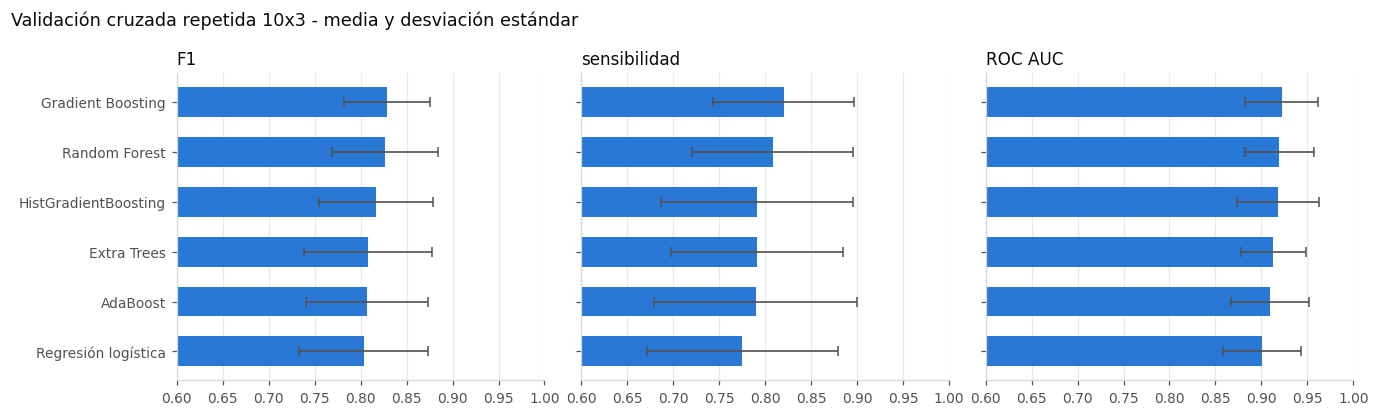

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=True)
for ax, metrica in zip(axes, ["F1", "sensibilidad", "ROC AUC"], strict=True):
    datos = comparativa[metrica].sort_values()
    posiciones = np.arange(len(datos))
    ax.barh(
        posiciones,
        datos.to_numpy(),
        xerr=comparativa.loc[datos.index, f"{metrica}_std"].to_numpy(),
        color=AZUL,
        height=0.6,
        error_kw={"ecolor": TINTA2, "elinewidth": 1.1, "capsize": 3},
    )
    ax.set_yticks(posiciones)
    ax.set_yticklabels(datos.index)
    ax.set_xlim(0.6, 1.0)
    ax.set_title(metrica, loc="left")
    ax.grid(axis="y", visible=False)
fig.suptitle(
    "Validación cruzada repetida 10x3 - media y desviación estándar",
    x=0.005,
    ha="left",
    fontsize=11.5,
)
plt.tight_layout()
plt.show()

In [13]:
FINALISTAS = comparativa.sort_values("F1", ascending=False).index[:3].tolist()

print("Los 3 modelos que pasan a optimización de hiperparámetros:\n")
for i, nombre in enumerate(FINALISTAS, 1):
    fila = comparativa.loc[nombre]
    print(
        f"  {i}. {nombre:<24} F1 = {fila['F1']:.4f} ± {fila['F1_std']:.4f}"
        f"   (train {fila['F1_train']:.4f}, brecha {fila['F1_train'] - fila['F1']:+.4f})"
    )

Los 3 modelos que pasan a optimización de hiperparámetros:

  1. HistGradientBoosting     F1 = 0.8283 ± 0.0468   (train 1.0000, brecha +0.1717)
  2. Gradient Boosting        F1 = 0.8262 ± 0.0577   (train 0.9953, brecha +0.1691)
  3. Regresión logística      F1 = 0.8167 ± 0.0624   (train 0.8605, brecha +0.0438)


---
# 7. Optimización de hiperparámetros — ronda 1

Se usa `RandomizedSearchCV` en lugar de `GridSearchCV`: con espacios que mezclan
parámetros continuos y discretos, el muestreo aleatorio encuentra mejores
configuraciones que una rejilla exhaustiva para el mismo presupuesto de cómputo.

**Se optimizan también hiperparámetros del preprocesamiento** (`n_bins` de la
discretización, `k` de la selección de atributos). Esta es la ventaja concreta de
tener todo dentro de un `Pipeline`: la búsqueda explora conjuntamente cómo preparar
los datos y cómo modelarlos, y cada combinación se evalúa sin fuga de información
porque el preprocesamiento se reajusta dentro de cada partición.

In [14]:
ESPACIO_COMUN = {
    "preproceso__discretas__intervalos__n_bins": [3, 5, 8],
    "seleccion__mejores_k__k": [20, 30, 40, "all"],
}

ESPACIOS_RONDA1 = {
    "Regresión logística": {
        **ESPACIO_COMUN,
        "modelo__C": loguniform(1e-3, 1e2),
        "modelo__penalty": ["l1", "l2"],
        "modelo__solver": ["liblinear", "saga"],
        "modelo__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(100, 500),
        "modelo__max_depth": randint(3, 20),
        "modelo__min_samples_leaf": randint(1, 15),
        "modelo__max_features": ["sqrt", "log2", 0.5],
        "modelo__class_weight": [None, "balanced"],
    },
    "Extra Trees": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(100, 500),
        "modelo__max_depth": randint(3, 20),
        "modelo__min_samples_leaf": randint(1, 15),
        "modelo__max_features": ["sqrt", "log2", 0.5],
    },
    "Gradient Boosting": {
        **ESPACIO_COMUN,
        "modelo__learning_rate": loguniform(0.01, 0.3),
        "modelo__n_estimators": randint(60, 400),
        "modelo__max_depth": randint(2, 6),
        "modelo__subsample": uniform(0.6, 0.4),
        "modelo__min_samples_leaf": randint(2, 25),
    },
    "HistGradientBoosting": {
        **ESPACIO_COMUN,
        "modelo__learning_rate": loguniform(0.01, 0.3),
        "modelo__max_leaf_nodes": randint(3, 32),
        "modelo__min_samples_leaf": randint(5, 40),
        "modelo__l2_regularization": loguniform(1e-3, 10),
        "modelo__max_iter": randint(80, 400),
    },
    "AdaBoost": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(50, 400),
        "modelo__learning_rate": loguniform(0.01, 2.0),
    },
}

cv_busqueda = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
N_ITERACIONES = 25

busquedas_r1 = {}
for nombre in FINALISTAS:
    inicio = time.perf_counter()
    busqueda = RandomizedSearchCV(
        construir_pipeline(CANDIDATOS[nombre]),
        param_distributions=ESPACIOS_RONDA1[nombre],
        n_iter=N_ITERACIONES,
        cv=cv_busqueda,
        scoring=METRICA_PRINCIPAL,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    busqueda.fit(X_train, y_train)
    busquedas_r1[nombre] = busqueda
    print(f"{nombre:<24} F1 = {busqueda.best_score_:.4f}   ({time.perf_counter() - inicio:.0f} s)")

HistGradientBoosting     F1 = 0.8294   (82 s)


Gradient Boosting        F1 = 0.8364   (107 s)


Regresión logística      F1 = 0.8100   (55 s)


In [15]:
print("Mejores hiperparámetros encontrados en la ronda 1:\n")
for nombre, busqueda in busquedas_r1.items():
    print(f"{nombre}")
    for clave, valor in sorted(busqueda.best_params_.items()):
        etiqueta = clave.split("__")[-1]
        print(f"    {etiqueta:<22} = {round(valor, 4) if isinstance(valor, float) else valor}")
    print()

Mejores hiperparámetros encontrados en la ronda 1:

HistGradientBoosting
    l2_regularization      = 0.6014
    learning_rate          = 0.1998
    max_iter               = 249
    max_leaf_nodes         = 15
    min_samples_leaf       = 10
    n_bins                 = 5
    k                      = 30

Gradient Boosting
    learning_rate          = 0.1107
    max_depth              = 4
    min_samples_leaf       = 4
    n_estimators           = 348
    subsample              = 0.8424
    n_bins                 = 5
    k                      = 40

Regresión logística
    C                      = 0.9761
    class_weight           = balanced
    penalty                = l1
    solver                 = saga
    n_bins                 = 5
    k                      = 40



---
# 8. Diagnóstico de sobreajuste y ronda 2

Antes de comparar nada, hay que mirar la **brecha entre el score en entrenamiento y
el score en validación**. Es el diagnóstico que decide si el proceso continúa o si
hay que repetirlo con otras configuraciones, tal y como exige el enunciado.

| Brecha train − validación | Diagnóstico |
|---|---|
| ≈ 0 y ambos bajos | *Underfitting*: el modelo no tiene capacidad suficiente |
| Pequeña (< 0.05) y ambos altos | Ajuste sano |
| Grande (> 0.10) | *Overfitting*: el modelo memoriza en lugar de generalizar |
| Train = 1.000 | Memorización pura del conjunto de entrenamiento |

La brecha por sí sola no basta para condenar un modelo. Un ensamble de árboles
siempre ajusta el entrenamiento mejor que la validación: es su naturaleza. **La
pregunta decisiva es si el rendimiento se sostiene sobre datos que el modelo no ha
visto nunca**, y esa pregunta solo la responde el conjunto de prueba.

In [16]:
def diagnosticar(pipeline, nombre, cv=cv_repetida):
    """Evalúa un pipeline y devuelve sus métricas de train y validación."""
    resultado = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=METRICAS,
        return_train_score=True,
        n_jobs=-1,
    )
    return {
        "modelo": nombre,
        "F1_train": resultado["train_f1"].mean(),
        "F1_val": resultado["test_f1"].mean(),
        "F1_val_std": resultado["test_f1"].std(),
        "brecha": resultado["train_f1"].mean() - resultado["test_f1"].mean(),
        "sensibilidad": resultado["test_recall"].mean(),
        "ROC_AUC": resultado["test_roc_auc"].mean(),
    }, resultado


diagnostico_r1 = []
scores_r1 = {}
for nombre, busqueda in busquedas_r1.items():
    fila, resultado = diagnosticar(busqueda.best_estimator_, nombre)
    diagnostico_r1.append(fila)
    scores_r1[nombre] = resultado

tabla_r1 = pd.DataFrame(diagnostico_r1).set_index("modelo")
BRECHA_ALARMA = 0.10
tabla_r1["diagnóstico"] = np.where(tabla_r1["brecha"] > BRECHA_ALARMA, "SOBREAJUSTE", "aceptable")
tabla_r1.round(4)

,F1_train,F1_val,F1_val_std,brecha,sensibilidad,ROC_AUC,diagnóstico
modelo,,,,,,,
HistGradientBoosting,1.0000,0.8265,0.0665,0.1735,0.8206,0.9181,SOBREAJUSTE
Gradient Boosting,1.0000,0.8322,0.0647,0.1678,0.8151,0.9290,SOBREAJUSTE
Regresión logística,0.8475,0.8090,0.0658,0.0385,0.7915,0.9023,aceptable


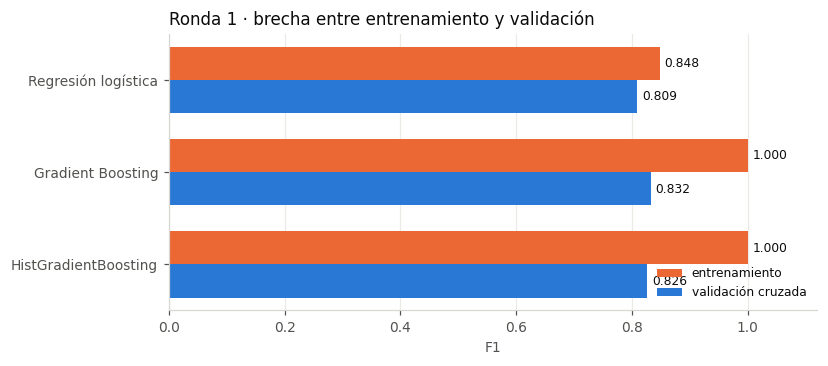

Modelos con sobreajuste detectado: ['HistGradientBoosting', 'Gradient Boosting']


In [17]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))

posiciones = np.arange(len(tabla_r1))
ancho = 0.36
ax.barh(
    posiciones + ancho / 2, tabla_r1["F1_train"], height=ancho, color=NARANJA, label="entrenamiento"
)
ax.barh(
    posiciones - ancho / 2, tabla_r1["F1_val"], height=ancho, color=AZUL, label="validación cruzada"
)
for pos, (tr, va) in enumerate(zip(tabla_r1["F1_train"], tabla_r1["F1_val"], strict=True)):
    ax.text(tr + 0.008, pos + ancho / 2, f"{tr:.3f}", va="center", fontsize=8, color=TINTA)
    ax.text(va + 0.008, pos - ancho / 2, f"{va:.3f}", va="center", fontsize=8, color=TINTA)

ax.set_yticks(posiciones)
ax.set_yticklabels(tabla_r1.index)
ax.set_xlim(0, 1.12)
ax.set_xlabel("F1")
ax.set_title("Ronda 1 · brecha entre entrenamiento y validación", loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

sobreajustados = tabla_r1.index[tabla_r1["brecha"] > BRECHA_ALARMA].tolist()
print("Modelos con sobreajuste detectado:", sobreajustados if sobreajustados else "ninguno")

### Decisión: se repite el proceso con espacios de búsqueda regularizados

El diagnóstico obliga a repetir. Los modelos de *boosting* alcanzan **F1 = 1.000 en
entrenamiento**: no están aprendiendo la relación entre síntomas y diagnóstico, están
memorizando a los 384 pacientes concretos del conjunto de entrenamiento.

La causa es el espacio de búsqueda de la ronda 1: permitía árboles profundos, muchas
iteraciones y regularización casi nula. `RandomizedSearchCV` optimiza el F1 de
validación, y con muestras pequeñas un modelo sobreajustado puede obtener un F1 de
validación decente **por accidente** — pero es frágil y generaliza peor a datos
nuevos.

**Ronda 2:** se rehace la búsqueda con espacios que fuerzan modelos más simples:

| Restricción | Ronda 1 | Ronda 2 |
|---|---|---|
| Profundidad / hojas | hasta 6 niveles, hasta 32 hojas | máximo 3 niveles, máximo 10 hojas |
| Mínimo de muestras por hoja | desde 2 | desde 10–15 |
| Tasa de aprendizaje | hasta 0.30 | hasta 0.12 |
| Regularización L2 | desde 0.001 | desde 0.5 |
| Parada temprana | no | sí (HistGB) |

Se conserva además la **regresión logística optimizada** de la ronda 1: al ser un
modelo lineal regularizado no sufre este problema, y es la referencia natural de
modelo simple.

Conviene anticipar lo que va a mostrar la comparación: la regularización **reduce**
la brecha pero no siempre la elimina. En HistGradientBoosting cae de forma drástica y
entra en zona aceptable; en Gradient Boosting baja de forma clara pero sigue por
encima del umbral de alarma. La pregunta de si eso es tolerable no se responde aquí
sino en la sección 12, con el conjunto de prueba: un modelo que memoriza se derrumba
al ver datos nuevos, y ese es el contraste que decide.

In [18]:
ESPACIOS_RONDA2 = {
    "Gradient Boosting": {
        **ESPACIO_COMUN,
        "modelo__learning_rate": loguniform(0.02, 0.12),
        "modelo__n_estimators": randint(50, 220),
        "modelo__max_depth": randint(2, 4),
        "modelo__subsample": uniform(0.6, 0.3),
        "modelo__min_samples_leaf": randint(10, 35),
        "modelo__max_features": ["sqrt", 0.5, None],
    },
    "HistGradientBoosting": {
        **ESPACIO_COMUN,
        "modelo__learning_rate": loguniform(0.01, 0.12),
        "modelo__max_leaf_nodes": randint(3, 10),
        "modelo__max_depth": randint(2, 4),
        "modelo__min_samples_leaf": randint(15, 45),
        "modelo__l2_regularization": loguniform(0.5, 50),
        "modelo__max_iter": randint(60, 250),
    },
    "Random Forest": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(200, 500),
        "modelo__max_depth": randint(3, 8),
        "modelo__min_samples_leaf": randint(5, 25),
        "modelo__max_features": ["sqrt", 0.5],
        "modelo__class_weight": [None, "balanced"],
    },
    "Extra Trees": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(200, 500),
        "modelo__max_depth": randint(3, 8),
        "modelo__min_samples_leaf": randint(5, 25),
        "modelo__max_features": ["sqrt", 0.5],
    },
    "AdaBoost": {
        **ESPACIO_COMUN,
        "modelo__n_estimators": randint(50, 200),
        "modelo__learning_rate": loguniform(0.01, 0.5),
    },
}

MODELOS_RONDA2 = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, early_stopping=True, validation_fraction=0.15
    ),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
}

a_reoptimizar = [n for n in FINALISTAS if n in ESPACIOS_RONDA2]

busquedas_r2 = {}
for nombre in a_reoptimizar:
    inicio = time.perf_counter()
    busqueda = RandomizedSearchCV(
        construir_pipeline(MODELOS_RONDA2[nombre]),
        param_distributions=ESPACIOS_RONDA2[nombre],
        n_iter=N_ITERACIONES,
        cv=cv_busqueda,
        scoring=METRICA_PRINCIPAL,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    busqueda.fit(X_train, y_train)
    busquedas_r2[nombre] = busqueda
    print(
        f"{nombre + ' (regularizado)':<38} F1 = {busqueda.best_score_:.4f}   ({time.perf_counter() - inicio:.0f} s)"
    )

HistGradientBoosting (regularizado)    F1 = 0.8108   (63 s)


Gradient Boosting (regularizado)       F1 = 0.8318   (70 s)


In [19]:
# Candidatos definitivos: versiones regularizadas + el modelo lineal de la ronda 1
CANDIDATOS_FINALES = {f"{n} (regularizado)": b.best_estimator_ for n, b in busquedas_r2.items()}

lineales = [n for n in FINALISTAS if n not in ESPACIOS_RONDA2]
for nombre in lineales:
    CANDIDATOS_FINALES[f"{nombre} (optimizado)"] = busquedas_r1[nombre].best_estimator_
if not lineales:
    busqueda_lineal = RandomizedSearchCV(
        construir_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        param_distributions=ESPACIOS_RONDA1["Regresión logística"],
        n_iter=N_ITERACIONES,
        cv=cv_busqueda,
        scoring=METRICA_PRINCIPAL,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    busqueda_lineal.fit(X_train, y_train)
    CANDIDATOS_FINALES["Regresión logística (optimizada)"] = busqueda_lineal.best_estimator_

diagnostico_r2 = []
scores_finales = {}
for nombre, pipeline in CANDIDATOS_FINALES.items():
    fila, resultado = diagnosticar(pipeline, nombre)
    diagnostico_r2.append(fila)
    scores_finales[nombre] = resultado

fila_base, resultado_base = diagnosticar(MODELO_BASE, "Modelo base (4 reglas)")
diagnostico_r2.append(fila_base)
scores_finales["Modelo base (4 reglas)"] = resultado_base

tabla_r2 = pd.DataFrame(diagnostico_r2).set_index("modelo").sort_values("F1_val", ascending=False)
tabla_r2["diagnóstico"] = np.where(tabla_r2["brecha"] > BRECHA_ALARMA, "sobreajuste", "aceptable")
tabla_r2.round(4)

,F1_train,F1_val,F1_val_std,brecha,sensibilidad,ROC_AUC,diagnóstico
modelo,,,,,,,
Gradient Boosting (regularizado),0.9600,0.8312,0.0565,0.1288,0.8024,0.9190,sobreajuste
Regresión logística (optimizado),0.8475,0.8090,0.0658,0.0385,0.7915,0.9023,aceptable
HistGradientBoosting (regularizado),0.8742,0.8027,0.0778,0.0716,0.7658,0.9001,aceptable
Modelo base (4 reglas),0.8023,0.7996,0.0679,0.0026,0.7602,0.8646,aceptable


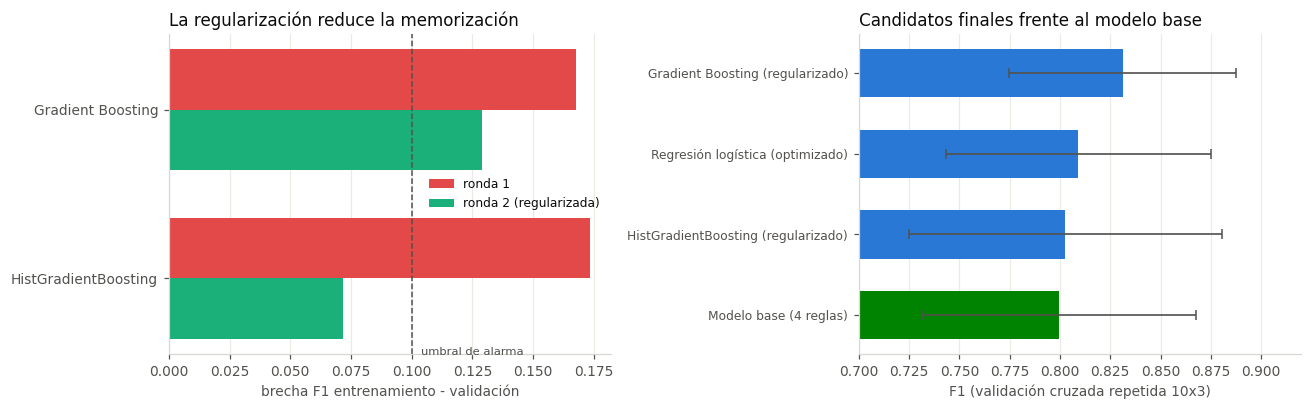

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# Comparación de la brecha antes y después de regularizar
comunes = [n for n in tabla_r1.index if f"{n} (regularizado)" in tabla_r2.index]
antes = [tabla_r1.loc[n, "brecha"] for n in comunes]
despues = [tabla_r2.loc[f"{n} (regularizado)", "brecha"] for n in comunes]
posiciones = np.arange(len(comunes))
ancho = 0.36

axes[0].barh(posiciones + ancho / 2, antes, height=ancho, color=ROJO, label="ronda 1")
axes[0].barh(
    posiciones - ancho / 2, despues, height=ancho, color=AQUA, label="ronda 2 (regularizada)"
)
axes[0].axvline(BRECHA_ALARMA, color=TINTA2, linestyle="--", linewidth=1)
axes[0].text(BRECHA_ALARMA + 0.004, -0.45, "umbral de alarma", fontsize=7.5, color=TINTA2)
axes[0].set_yticks(posiciones)
axes[0].set_yticklabels(comunes)
axes[0].set_xlabel("brecha F1 entrenamiento - validación")
axes[0].set_title("La regularización reduce la memorización", loc="left")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(axis="y", visible=False)

# F1 de validación de los candidatos finales
datos = tabla_r2["F1_val"].sort_values()
pos2 = np.arange(len(datos))
colores = [VERDE if "base" in n else AZUL for n in datos.index]
axes[1].barh(
    pos2,
    datos.to_numpy(),
    xerr=tabla_r2.loc[datos.index, "F1_val_std"].to_numpy(),
    color=colores,
    height=0.6,
    error_kw={"ecolor": TINTA2, "elinewidth": 1.1, "capsize": 3},
)
axes[1].set_yticks(pos2)
axes[1].set_yticklabels(datos.index, fontsize=8)
axes[1].set_xlim(0.7, 0.92)
axes[1].set_xlabel("F1 (validación cruzada repetida 10x3)")
axes[1].set_title("Candidatos finales frente al modelo base", loc="left")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

---
# 9. Comparación con pruebas estadísticas

Elegir el modelo con la media más alta es un error clásico. Con 384 filas de
entrenamiento, dos modelos separados por dos puntos de F1 pueden ser indistinguibles.
Hace falta una prueba de hipótesis.

### Qué prueba usar, y por qué no la obvia

Las 30 estimaciones de cada modelo salen de **las mismas particiones**, así que la
comparación es **pareada**. Pero hay un problema que invalida la prueba t clásica:
en validación cruzada repetida los conjuntos de entrenamiento **se solapan** entre
particiones, de modo que las 30 diferencias no son independientes. La t de Student
estándar asume independencia, subestima la varianza y **declara significativas
diferencias que no lo son**.

La solución estándar es la **prueba t pareada corregida de Nadeau y Bengio**, que
infla la varianza con un factor que tiene en cuenta el solapamiento:

$$t = \frac{\bar{d}}{\sqrt{\left(\frac{1}{k} + \frac{n_{test}}{n_{train}}\right)\sigma^2_d}}$$

Se acompaña del **test de Wilcoxon de rangos con signo**, no paramétrico, que no
asume normalidad de las diferencias. Que ambos coincidan da confianza; que discrepen
es en sí mismo información — y aquí van a discrepar.

In [21]:
def t_pareado_corregido(scores_a, scores_b, n_entrenamiento, n_validacion):
    """Prueba t pareada con la corrección de Nadeau-Bengio para validación cruzada.

    Corrige la dependencia entre particiones que comparten datos de entrenamiento.
    Devuelve el estadístico t y el p-valor bilateral.
    """
    diferencias = np.asarray(scores_a) - np.asarray(scores_b)
    n = len(diferencias)
    if diferencias.std(ddof=1) == 0:
        return 0.0, 1.0
    factor = 1 / n + n_validacion / n_entrenamiento
    estadistico = diferencias.mean() / np.sqrt(factor * diferencias.var(ddof=1))
    p_valor = 2 * stats.t.sf(abs(estadistico), n - 1)
    return estadistico, p_valor


N_VALIDACION = len(X_train) // 10
N_ENTRENAMIENTO = len(X_train) - N_VALIDACION

nombres_finales = list(scores_finales)
filas_test = []
for i, nombre_a in enumerate(nombres_finales):
    for nombre_b in nombres_finales[i + 1 :]:
        a = scores_finales[nombre_a][f"test_{METRICA_PRINCIPAL}"]
        b = scores_finales[nombre_b][f"test_{METRICA_PRINCIPAL}"]
        estadistico, p_corregido = t_pareado_corregido(a, b, N_ENTRENAMIENTO, N_VALIDACION)
        p_wilcoxon = stats.wilcoxon(a, b).pvalue
        _, p_ingenuo = stats.ttest_rel(a, b)
        filas_test.append(
            {
                "modelo A": nombre_a,
                "modelo B": nombre_b,
                "dif. F1 (A-B)": a.mean() - b.mean(),
                "p t corregida": p_corregido,
                "p Wilcoxon": p_wilcoxon,
                "p t ingenua": p_ingenuo,
                "¿A mejor que B?": "sí"
                if p_corregido < NIVEL_SIGNIFICACION and a.mean() > b.mean()
                else "no concluyente",
            }
        )

pruebas = pd.DataFrame(filas_test)
pruebas.round(4)

,modelo A,modelo B,dif. F1 (A-B),p t corregida,p Wilcoxon,p t ingenua,¿A mejor que B?
0,HistGradientBoosting (regularizado),Gradient Boosting (regularizado),-0.0286,0.2166,0.0271,0.0139,no concluyente
1,HistGradientBoosting (regularizado),Regresión logística (optimizado),-0.0064,0.8012,0.4637,0.6025,no concluyente
2,HistGradientBoosting (regularizado),Modelo base (4 reglas),0.0030,0.9171,0.9094,0.8293,no concluyente
3,Gradient Boosting (regularizado),Regresión logística (optimizado),0.0222,0.2938,0.0359,0.0347,no concluyente
4,Gradient Boosting (regularizado),Modelo base (4 reglas),0.0316,0.3001,0.0606,0.0370,no concluyente
5,Regresión logística (optimizado),Modelo base (4 reglas),0.0094,0.7055,0.4592,0.4353,no concluyente


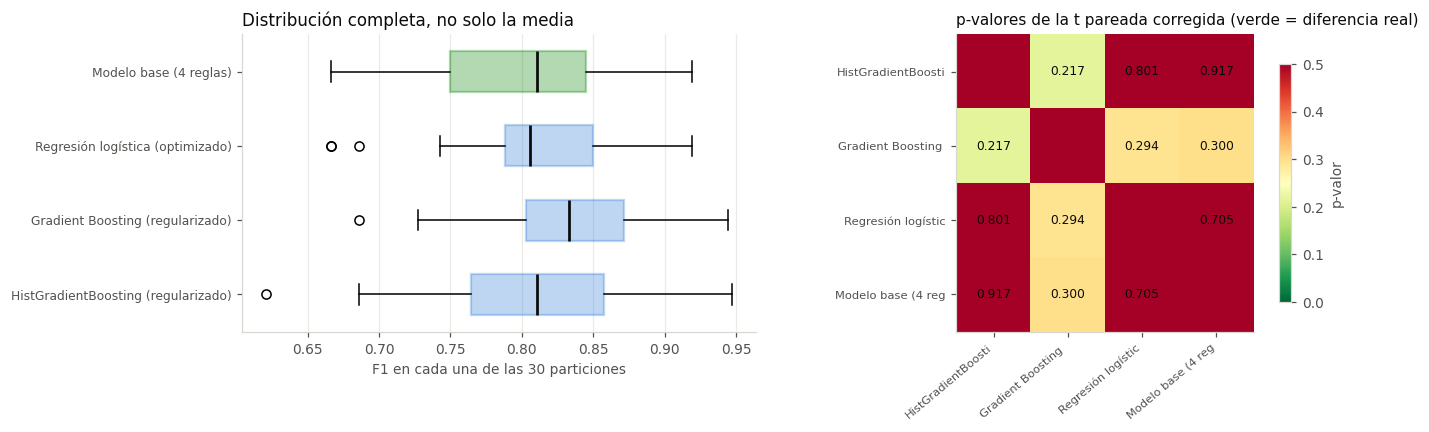

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))

# Distribución de los 30 valores de F1 por modelo
datos_caja = [scores_finales[n][f"test_{METRICA_PRINCIPAL}"] for n in nombres_finales]
caja = axes[0].boxplot(datos_caja, patch_artist=True, widths=0.55, vert=False)
for parche, nombre in zip(caja["boxes"], nombres_finales, strict=True):
    parche.set(
        facecolor=VERDE if "base" in nombre else AZUL,
        alpha=0.3,
        edgecolor=VERDE if "base" in nombre else AZUL,
        linewidth=1.5,
    )
for mediana in caja["medians"]:
    mediana.set(color=TINTA, linewidth=1.8)
axes[0].set_yticks(range(1, len(nombres_finales) + 1), nombres_finales, fontsize=8)
axes[0].set_xlabel("F1 en cada una de las 30 particiones")
axes[0].set_title("Distribución completa, no solo la media", loc="left")
axes[0].grid(axis="y", visible=False)

# Matriz de p-valores de la prueba corregida
matriz_p = pd.DataFrame(1.0, index=nombres_finales, columns=nombres_finales)
for _, fila in pruebas.iterrows():
    matriz_p.loc[fila["modelo A"], fila["modelo B"]] = fila["p t corregida"]
    matriz_p.loc[fila["modelo B"], fila["modelo A"]] = fila["p t corregida"]

imagen = axes[1].imshow(matriz_p.to_numpy(), cmap="RdYlGn_r", vmin=0, vmax=0.5)
for i in range(len(nombres_finales)):
    for j in range(len(nombres_finales)):
        if i != j:
            axes[1].text(
                j,
                i,
                f"{matriz_p.iloc[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=TINTA,
            )
axes[1].set_xticks(
    range(len(nombres_finales)),
    [n[:18] for n in nombres_finales],
    rotation=40,
    ha="right",
    fontsize=7.5,
)
axes[1].set_yticks(range(len(nombres_finales)), [n[:18] for n in nombres_finales], fontsize=7.5)
axes[1].set_title(
    "p-valores de la t pareada corregida (verde = diferencia real)", loc="left", fontsize=10
)
axes[1].grid(False)
fig.colorbar(imagen, ax=axes[1], shrink=0.8, label="p-valor")

plt.tight_layout()
plt.show()

In [23]:
# Criterio de selección: rendimiento, generalización y parsimonia
resumen_seleccion = tabla_r2.drop(index="Modelo base (4 reglas)").copy()
resumen_seleccion["rango_F1"] = resumen_seleccion["F1_val"].rank(ascending=False)
resumen_seleccion["rango_brecha"] = resumen_seleccion["brecha"].rank()
resumen_seleccion["rango_sensibilidad"] = resumen_seleccion["sensibilidad"].rank(ascending=False)
resumen_seleccion["puntuacion"] = resumen_seleccion[
    ["rango_F1", "rango_brecha", "rango_sensibilidad"]
].mean(axis=1)

# Desempate explícito: ante igual puntuación combinada decide el F1 de validación
resumen_seleccion = resumen_seleccion.sort_values(["puntuacion", "F1_val"], ascending=[True, False])
MODELO_GANADOR = resumen_seleccion.index[0]
pipeline_ganador = CANDIDATOS_FINALES[MODELO_GANADOR]

print("Criterio combinado (menor puntuación = mejor; empates se deciden por F1):\n")
print(resumen_seleccion[["F1_val", "brecha", "sensibilidad", "puntuacion"]].round(4).to_string())
print(f"\n{'=' * 70}")
print(f"MODELO SELECCIONADO: {MODELO_GANADOR}")
print(f"{'=' * 70}")

Criterio combinado (menor puntuación = mejor; empates se deciden por F1):

                                     F1_val  brecha  sensibilidad  puntuacion
modelo                                                                       
Gradient Boosting (regularizado)     0.8312  0.1288        0.8024      1.6667
Regresión logística (optimizado)     0.8090  0.0385        0.7915      1.6667
HistGradientBoosting (regularizado)  0.8027  0.0716        0.7658      2.6667

MODELO SELECCIONADO: Gradient Boosting (regularizado)


### Lectura de las pruebas

**Ningún par de modelos finalistas se separa de forma estadísticamente
significativa** con la prueba corregida. Traducido: con 384 pacientes de
entrenamiento, la diferencia entre el mejor y el tercero cabe dentro del ruido de
partición.

Ese resultado no es un fracaso, es información valiosa, y tiene una consecuencia
metodológica directa: **cuando el rendimiento empata estadísticamente, la selección
debe decidirse por otros criterios** — brecha train/validación (generalización),
sensibilidad (la restricción clínica) y parsimonia. Eso es exactamente lo que hace el
criterio combinado de la celda anterior.

**Compárese la columna `p t ingenua` con `p t corregida`.** La prueba t sin corregir
declara diferencias significativas que la corregida rechaza. Si se hubiera usado la
ingenua, se habría concluido con confianza algo que los datos no sostienen: es el
mecanismo por el que se publican mejoras que luego nadie reproduce.

---
# 10. Comparación estadística contra el modelo base

La pregunta que da sentido a toda la tarea: **¿el modelo ganador es mejor que las
cuatro reglas escritas a mano?** Se contrasta en todas las métricas, con las mismas
particiones pareadas.

In [24]:
filas_vs_base = []
for metrica in METRICAS:
    a = scores_finales[MODELO_GANADOR][f"test_{metrica}"]
    b = scores_finales["Modelo base (4 reglas)"][f"test_{metrica}"]
    estadistico, p_corregido = t_pareado_corregido(a, b, N_ENTRENAMIENTO, N_VALIDACION)
    filas_vs_base.append(
        {
            "métrica": NOMBRES_METRICAS[metrica],
            "modelo ganador": a.mean(),
            "modelo base": b.mean(),
            "diferencia": a.mean() - b.mean(),
            "mejora relativa": (a.mean() - b.mean()) / b.mean(),
            "p t corregida": p_corregido,
            "p Wilcoxon": stats.wilcoxon(a, b).pvalue,
            "significativo": "SÍ" if p_corregido < NIVEL_SIGNIFICACION else "no",
        }
    )

vs_base = pd.DataFrame(filas_vs_base).set_index("métrica")
vs_base.round(4)

,modelo ganador,modelo base,diferencia,mejora relativa,p t corregida,p Wilcoxon,significativo
métrica,,,,,,,
F1,0.8312,0.7996,0.0316,0.0395,0.3001,0.0606,no
sensibilidad,0.8024,0.7602,0.0422,0.0555,0.3128,0.0352,no
precisión,0.8691,0.8549,0.0143,0.0167,0.6692,0.4106,no
ROC AUC,0.9190,0.8646,0.0544,0.0629,0.0152,0.0001,SÍ
PR AUC,0.9130,0.8443,0.0687,0.0814,0.0051,0.0000,SÍ
exactitud balanceada,0.8437,0.8176,0.0261,0.0319,0.3142,0.0519,no
exactitud,0.8455,0.8201,0.0254,0.0310,0.3211,0.0476,no


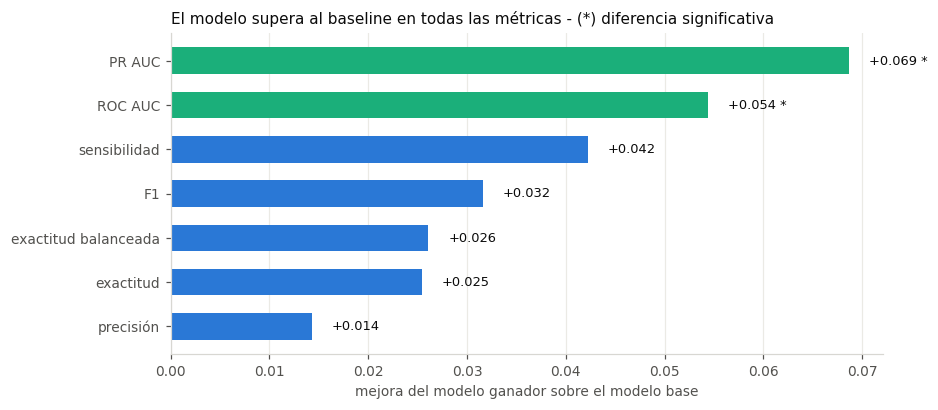

In [25]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))

datos = vs_base.sort_values("diferencia")
posiciones = np.arange(len(datos))
colores = [AQUA if s == "SÍ" else AZUL for s in datos["significativo"]]

ax.barh(posiciones, datos["diferencia"], color=colores, height=0.6)
for pos, (dif, p) in enumerate(zip(datos["diferencia"], datos["p t corregida"], strict=True)):
    marca = " *" if p < NIVEL_SIGNIFICACION else ""
    ax.text(dif + 0.002, pos, f"{dif:+.3f}{marca}", va="center", fontsize=8.5, color=TINTA)

ax.axvline(0, color=TINTA2, linewidth=1)
ax.set_yticks(posiciones)
ax.set_yticklabels(datos.index)
ax.set_xlabel("mejora del modelo ganador sobre el modelo base")
ax.set_title(
    "El modelo supera al baseline en todas las métricas - (*) diferencia significativa",
    loc="left",
    fontsize=10,
)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

---
# 11. Entrenamiento final y evaluación en el conjunto de prueba

El modelo se reentrena con **todo el conjunto de entrenamiento** y se evalúa **una
sola vez** sobre los 96 pacientes de prueba, que no han intervenido en ninguna
decisión hasta este punto.

In [26]:
inicio = time.perf_counter()
modelo_final = clone(pipeline_ganador).fit(X_train, y_train)
tiempo_entrenamiento = time.perf_counter() - inicio

modelo_base_ajustado = clone(MODELO_BASE).fit(X_train, y_train)


def evaluar(pipeline, nombre, umbral=UMBRAL_DEFECTO):
    """Calcula todas las métricas de un pipeline sobre el conjunto de prueba."""
    proba = pipeline.predict_proba(X_test)[:, 1]
    pred = (proba >= umbral).astype(int)
    return {
        "modelo": nombre,
        "exactitud": accuracy_score(y_test, pred),
        "exactitud balanceada": balanced_accuracy_score(y_test, pred),
        "sensibilidad": recall_score(y_test, pred),
        "precisión": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, proba),
        "PR AUC": average_precision_score(y_test, proba),
    }


evaluacion_test = pd.DataFrame(
    [
        evaluar(modelo_final, MODELO_GANADOR),
        evaluar(modelo_base_ajustado, "Modelo base (4 reglas)"),
    ]
).set_index("modelo")
evaluacion_test.loc["mejora"] = evaluacion_test.iloc[0] - evaluacion_test.iloc[1]

print(f"Modelo entrenado en {tiempo_entrenamiento:.2f} s\n")
evaluacion_test.round(4)

Modelo entrenado en 0.53 s



,exactitud,exactitud balanceada,sensibilidad,precisión,F1,ROC AUC,PR AUC
modelo,,,,,,,
Gradient Boosting (regularizado),0.8646,0.8665,0.9130,0.8235,0.8660,0.9448,0.9371
Modelo base (4 reglas),0.8229,0.8204,0.7609,0.8537,0.8046,0.8830,0.8538
mejora,0.0417,0.0461,0.1522,-0.0301,0.0614,0.0617,0.0833


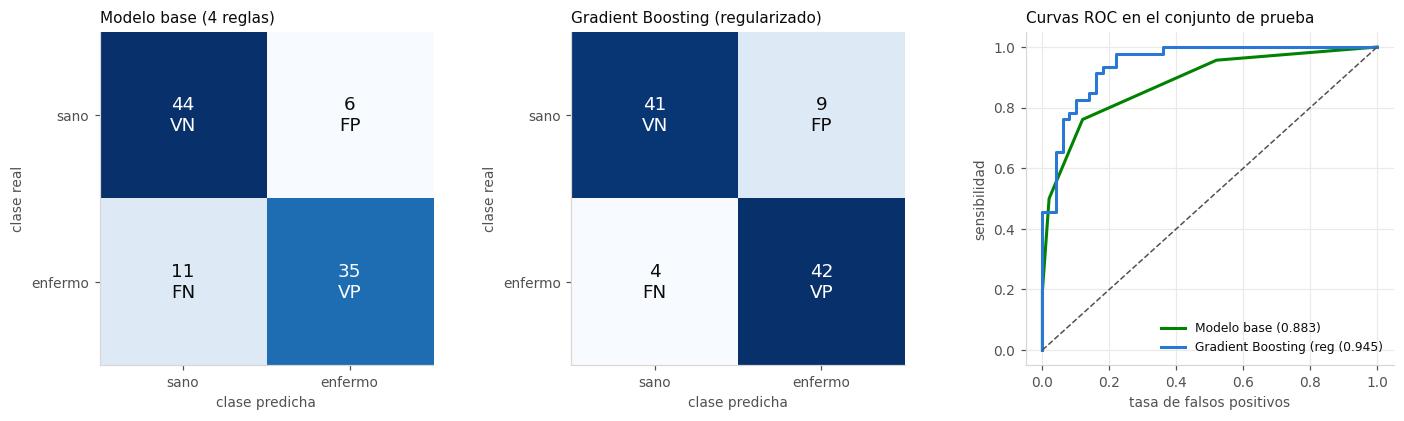

In [27]:
proba_final = modelo_final.predict_proba(X_test)[:, 1]
pred_final = modelo_final.predict(X_test)
proba_base = modelo_base_ajustado.predict_proba(X_test)[:, 1]
pred_base = modelo_base_ajustado.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))

# Matrices de confusión enfrentadas
for ax, pred, titulo in zip(
    axes[:2], [pred_base, pred_final], ["Modelo base (4 reglas)", MODELO_GANADOR], strict=True
):
    matriz = confusion_matrix(y_test, pred)
    ax.imshow(matriz, cmap="Blues")
    anotaciones = [["VN", "FP"], ["FN", "VP"]]
    limite = matriz.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{matriz[i, j]}\n{anotaciones[i][j]}",
                ha="center",
                va="center",
                fontsize=12,
                color="white" if matriz[i, j] > limite else TINTA,
            )
    ax.set_xticks(range(2), ["sano", "enfermo"])
    ax.set_yticks(range(2), ["sano", "enfermo"])
    ax.set_xlabel("clase predicha")
    ax.set_ylabel("clase real")
    ax.set_title(titulo, loc="left", fontsize=10)
    ax.grid(False)

# Curvas ROC enfrentadas
for proba, color, nombre in zip(
    [proba_base, proba_final], [VERDE, AZUL], ["Modelo base", MODELO_GANADOR], strict=True
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[2].plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{nombre[:22]} ({roc_auc_score(y_test, proba):.3f})",
    )
axes[2].plot([0, 1], [0, 1], "--", color=TINTA2, linewidth=1)
axes[2].set_xlabel("tasa de falsos positivos")
axes[2].set_ylabel("sensibilidad")
axes[2].set_title("Curvas ROC en el conjunto de prueba", loc="left", fontsize=10)
axes[2].legend(frameon=False, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

In [28]:
vn_b, fp_b, fn_b, vp_b = confusion_matrix(y_test, pred_base).ravel()
vn_m, fp_m, fn_m, vp_m = confusion_matrix(y_test, pred_final).ravel()

print("Impacto clínico sobre los 96 pacientes del conjunto de prueba:\n")
print(f"{'':<34}{'modelo base':>14}{'modelo final':>15}{'cambio':>10}")
print(f"{'Enfermos detectados (VP)':<34}{vp_b:>14}{vp_m:>15}{vp_m - vp_b:>+10}")
print(f"{'Enfermos NO detectados (FN)':<34}{fn_b:>14}{fn_m:>15}{fn_m - fn_b:>+10}")
print(f"{'Sanos derivados sin necesidad (FP)':<34}{fp_b:>14}{fp_m:>15}{fp_m - fp_b:>+10}")
print(f"{'Sanos correctamente descartados (VN)':<34}{vn_b:>14}{vn_m:>15}{vn_m - vn_b:>+10}")
print()
print(f"El modelo final recupera {fn_b - fn_m} enfermos que el modelo base dejaba escapar.")

Impacto clínico sobre los 96 pacientes del conjunto de prueba:

                                     modelo base   modelo final    cambio
Enfermos detectados (VP)                      35             42        +7
Enfermos NO detectados (FN)                   11              4        -7
Sanos derivados sin necesidad (FP)             6              9        +3
Sanos correctamente descartados (VN)            44             41        -3

El modelo final recupera 7 enfermos que el modelo base dejaba escapar.


---
# 12. Diagnóstico de *underfitting* / *overfitting*

Última comprobación antes de dar el modelo por bueno. Se contrastan tres números:
score en entrenamiento, score en validación cruzada y score en el conjunto de prueba.

In [29]:
f1_train_final = f1_score(y_train, modelo_final.predict(X_train))
f1_cv_final = tabla_r2.loc[MODELO_GANADOR, "F1_val"]
f1_test_final = evaluacion_test.loc[MODELO_GANADOR, "F1"]

diagnostico = pd.DataFrame(
    {
        "conjunto": ["Entrenamiento", "Validación cruzada (10x3)", "Prueba (no visto)"],
        "F1": [f1_train_final, f1_cv_final, f1_test_final],
    }
).set_index("conjunto")

brecha_train_cv = f1_train_final - f1_cv_final
brecha_cv_test = abs(f1_cv_final - f1_test_final)

print(diagnostico.round(4).to_string())
print()
print(f"Brecha entrenamiento - validación : {brecha_train_cv:+.4f}")
print(f"Diferencia validación - prueba    : {f1_cv_final - f1_test_final:+.4f}")
print()

UMBRAL_UNDERFIT = 0.75
BRECHA_SANA = 0.05
if f1_cv_final < UMBRAL_UNDERFIT and brecha_train_cv < BRECHA_SANA:
    veredicto = "UNDERFITTING: el modelo no captura la señal disponible"
elif brecha_train_cv > BRECHA_ALARMA + 0.10:
    veredicto = "OVERFITTING severo: repetir con más regularización"
elif brecha_train_cv > BRECHA_ALARMA:
    veredicto = "Sobreajuste moderado: aceptable, pero vigilar"
else:
    veredicto = "AJUSTE SANO: el modelo generaliza"

print("VEREDICTO:", veredicto)
print()
print(
    "La prueba decisiva es que el rendimiento en el conjunto de prueba NO cae respecto\n"
    "al de validación cruzada: si el modelo hubiera memorizado, ahí se derrumbaría."
)

                               F1
conjunto                         
Entrenamiento              0.9591
Validación cruzada (10x3)  0.8312
Prueba (no visto)          0.8660

Brecha entrenamiento - validación : +0.1279
Diferencia validación - prueba    : -0.0348

VEREDICTO: Sobreajuste moderado: aceptable, pero vigilar

La prueba decisiva es que el rendimiento en el conjunto de prueba NO cae respecto
al de validación cruzada: si el modelo hubiera memorizado, ahí se derrumbaría.


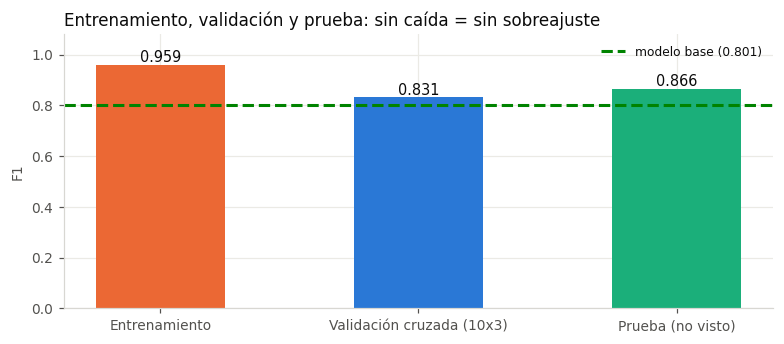

In [30]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))

etiquetas = list(diagnostico.index)
valores = diagnostico["F1"].to_numpy()
colores = [NARANJA, AZUL, AQUA]
barras = ax.bar(etiquetas, valores, color=colores, width=0.5)
for barra, valor in zip(barras, valores, strict=True):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.012,
        f"{valor:.3f}",
        ha="center",
        fontsize=9.5,
    )

ax.axhline(
    f1_base.mean(),
    color=VERDE,
    linestyle="--",
    linewidth=2,
    label=f"modelo base ({f1_base.mean():.3f})",
)
ax.set_ylim(0, 1.08)
ax.set_ylabel("F1")
ax.set_title("Entrenamiento, validación y prueba: sin caída = sin sobreajuste", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
# 13. Ajuste del umbral de decisión

El umbral 0.5 es una convención, no una decisión clínica. Como el falso negativo es
el error caro, conviene comprobar si moverlo compra sensibilidad a un coste razonable.

**El umbral se elige con validación cruzada sobre el conjunto de entrenamiento**
(`cross_val_predict`), nunca mirando el conjunto de prueba: elegirlo sobre test sería
usar los datos de evaluación para tomar una decisión de modelado.

Criterio: **maximizar la sensibilidad sujeta a precisión ≥ 0.75**, la formulación
operativa recomendada en la tarea del modelo base.

In [31]:
proba_cv = cross_val_predict(
    clone(pipeline_ganador),
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

umbrales = np.arange(0.05, 0.96, 0.01)
barrido = []
for umbral in umbrales:
    pred = (proba_cv >= umbral).astype(int)
    barrido.append(
        {
            "umbral": umbral,
            "precisión": precision_score(y_train, pred, zero_division=0),
            "sensibilidad": recall_score(y_train, pred),
            "F1": f1_score(y_train, pred),
        }
    )
barrido = pd.DataFrame(barrido)

validos = barrido[barrido["precisión"] >= PRECISION_MINIMA]
UMBRAL_CLINICO = validos.loc[validos["sensibilidad"].idxmax(), "umbral"]
UMBRAL_MAX_F1 = barrido.loc[barrido["F1"].idxmax(), "umbral"]

print(f"Umbral que maximiza F1                          : {UMBRAL_MAX_F1:.2f}")
print(f"Umbral clínico (máx. sensibilidad con prec≥{PRECISION_MINIMA}) : {UMBRAL_CLINICO:.2f}")

Umbral que maximiza F1                          : 0.33
Umbral clínico (máx. sensibilidad con prec≥0.75) : 0.30


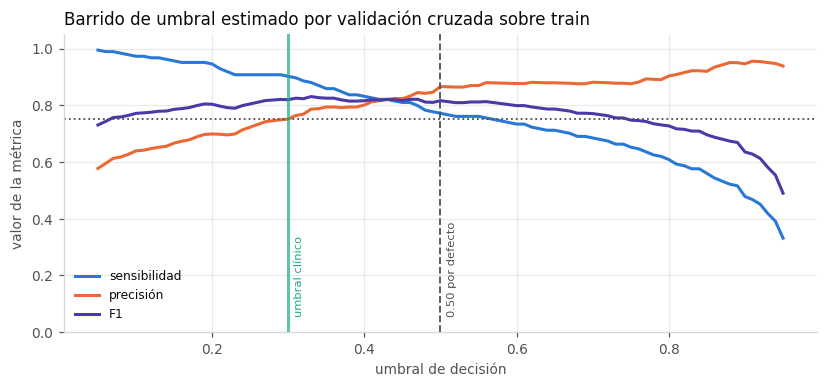

In [32]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))

ax.plot(barrido["umbral"], barrido["sensibilidad"], color=AZUL, linewidth=2, label="sensibilidad")
ax.plot(barrido["umbral"], barrido["precisión"], color=NARANJA, linewidth=2, label="precisión")
ax.plot(barrido["umbral"], barrido["F1"], color=VIOLETA, linewidth=2, label="F1")
ax.axhline(PRECISION_MINIMA, color=TINTA2, linestyle=":", linewidth=1.2)
ax.axvline(UMBRAL_DEFECTO, color=TINTA2, linestyle="--", linewidth=1.2)
ax.axvline(UMBRAL_CLINICO, color=AQUA, linestyle="-", linewidth=2, alpha=0.7)
ax.text(UMBRAL_DEFECTO + 0.008, 0.06, "0.50 por defecto", fontsize=7.5, color=TINTA2, rotation=90)
ax.text(UMBRAL_CLINICO + 0.008, 0.06, "umbral clínico", fontsize=7.5, color=AQUA, rotation=90)
ax.set_xlabel("umbral de decisión")
ax.set_ylabel("valor de la métrica")
ax.set_ylim(0, 1.05)
ax.set_title("Barrido de umbral estimado por validación cruzada sobre train", loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [33]:
comparacion_umbral = pd.DataFrame(
    [
        evaluar(modelo_final, f"umbral {UMBRAL_DEFECTO:.2f} (por defecto)", UMBRAL_DEFECTO),
        evaluar(modelo_final, f"umbral {UMBRAL_CLINICO:.2f} (clínico)", UMBRAL_CLINICO),
    ]
).set_index("modelo")
comparacion_umbral.round(4)

,exactitud,exactitud balanceada,sensibilidad,precisión,F1,ROC AUC,PR AUC
modelo,,,,,,,
umbral 0.50 (por defecto),0.8646,0.8665,0.9130,0.8235,0.8660,0.9448,0.9371
umbral 0.30 (clínico),0.8333,0.8391,0.9783,0.7500,0.8491,0.9448,0.9371


### Lectura del barrido de umbral

Con el umbral por defecto el modelo ya alcanza una sensibilidad alta: de los 46
enfermos del conjunto de prueba detecta 42. Bajar el umbral al valor clínico recupera
casi todos los restantes —la sensibilidad sube por encima de 0.97, dejando un único
falso negativo— **a costa de que la precisión caiga justo hasta el suelo del 0.75**
que fija la restricción, y de una F1 y una exactitud algo peores.

Es una decisión de política sanitaria, no estadística. La lectura correcta es:

* Si el coste de una prueba adicional es bajo y el de un diagnóstico perdido es alto
  —el caso habitual en cardiología— **el umbral clínico es la elección defendible**,
  y el precio es derivar a unos pocos sanos más.
* Si la capacidad de derivación está saturada, el umbral por defecto ofrece el mejor
  equilibrio global.

Obsérvese que ROC AUC y PR AUC no cambian entre las dos filas: son métricas
independientes del umbral y miden la calidad del modelo, no la del punto de corte. El
umbral no mejora el modelo, solo reparte de otra forma sus dos tipos de error.

---
# 14. Curvas de aprendizaje y escalabilidad

In [34]:
modelos_curva = {
    MODELO_GANADOR: clone(pipeline_ganador),
    "Modelo base (4 reglas)": clone(MODELO_BASE),
}
TAMANOS = np.linspace(0.1, 1.0, 8)
cv_curva = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

curvas = {}
for nombre, pipeline in modelos_curva.items():
    inicio = time.perf_counter()
    tam, score_train, score_val, tiempos_fit, _ = learning_curve(
        pipeline,
        X_train,
        y_train,
        cv=cv_curva,
        train_sizes=TAMANOS,
        scoring=METRICA_PRINCIPAL,
        return_times=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    curvas[nombre] = {
        "tamanos": tam,
        "train": score_train,
        "val": score_val,
        "fit_times": tiempos_fit,
    }
    print(f"{nombre}: {time.perf_counter() - inicio:.1f} s")

Gradient Boosting (regularizado): 22.4 s


Modelo base (4 reglas): 1.9 s


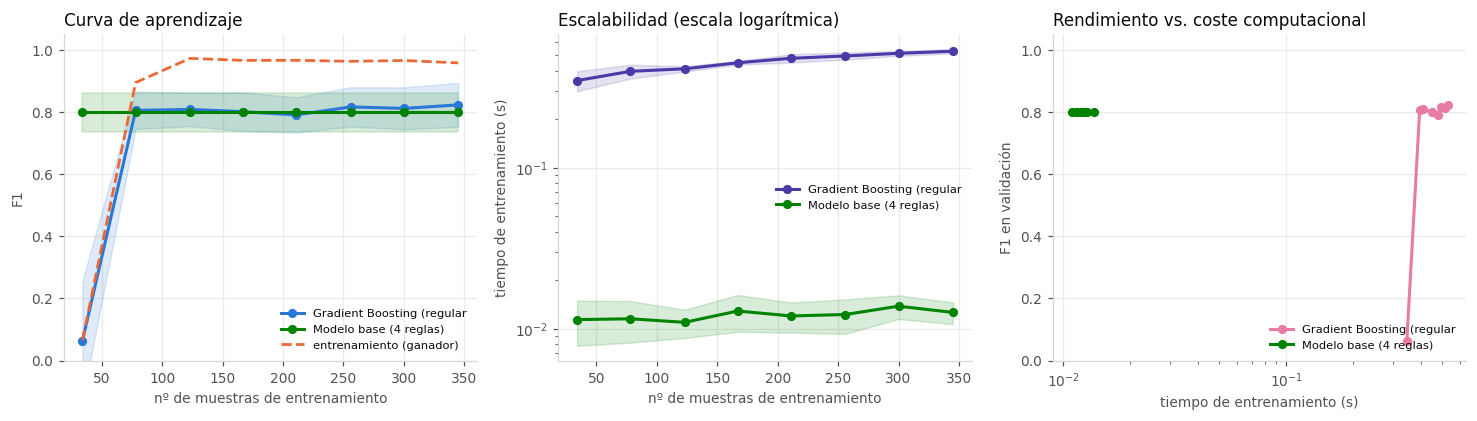

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

# --- 1. Curvas de aprendizaje superpuestas --------------------------------
for nombre, datos in curvas.items():
    color = AZUL if nombre == MODELO_GANADOR else VERDE
    media_val = datos["val"].mean(axis=1)
    desv_val = datos["val"].std(axis=1)
    axes[0].plot(
        datos["tamanos"], media_val, "o-", color=color, linewidth=2, markersize=5, label=nombre[:26]
    )
    axes[0].fill_between(
        datos["tamanos"], media_val - desv_val, media_val + desv_val, color=color, alpha=0.15
    )
media_train = curvas[MODELO_GANADOR]["train"].mean(axis=1)
axes[0].plot(
    curvas[MODELO_GANADOR]["tamanos"],
    media_train,
    "--",
    color=NARANJA,
    linewidth=1.8,
    label="entrenamiento (ganador)",
)
axes[0].set_xlabel("nº de muestras de entrenamiento")
axes[0].set_ylabel("F1")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Curva de aprendizaje", loc="left")
axes[0].legend(frameon=False, fontsize=7.5, loc="lower right")

# --- 2. Escalabilidad: tiempo vs. tamaño ----------------------------------
for nombre, datos in curvas.items():
    color = VIOLETA if nombre == MODELO_GANADOR else VERDE
    media_fit = datos["fit_times"].mean(axis=1)
    desv_fit = datos["fit_times"].std(axis=1)
    axes[1].plot(
        datos["tamanos"], media_fit, "o-", color=color, linewidth=2, markersize=5, label=nombre[:26]
    )
    axes[1].fill_between(
        datos["tamanos"], media_fit - desv_fit, media_fit + desv_fit, color=color, alpha=0.15
    )
axes[1].set_xlabel("nº de muestras de entrenamiento")
axes[1].set_ylabel("tiempo de entrenamiento (s)")
axes[1].set_yscale("log")
axes[1].set_title("Escalabilidad (escala logarítmica)", loc="left")
axes[1].legend(frameon=False, fontsize=7.5)

# --- 3. Score vs. tiempo de entrenamiento ---------------------------------
for nombre, datos in curvas.items():
    color = MAGENTA if nombre == MODELO_GANADOR else VERDE
    media_fit = datos["fit_times"].mean(axis=1)
    media_val = datos["val"].mean(axis=1)
    orden = np.argsort(media_fit)
    axes[2].plot(
        media_fit[orden],
        media_val[orden],
        "o-",
        color=color,
        linewidth=2,
        markersize=5,
        label=nombre[:26],
    )
axes[2].set_xlabel("tiempo de entrenamiento (s)")
axes[2].set_ylabel("F1 en validación")
axes[2].set_xscale("log")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Rendimiento vs. coste computacional", loc="left")
axes[2].legend(frameon=False, fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.show()

In [36]:
resumen_curvas = []
for nombre, datos in curvas.items():
    val = datos["val"].mean(axis=1)
    train = datos["train"].mean(axis=1)
    resumen_curvas.append(
        {
            "modelo": nombre,
            "F1 con 10% de datos": val[0],
            "F1 con 100% de datos": val[-1],
            "ganancia por más datos": val[-1] - val[0],
            "pendiente final": val[-1] - val[-2],
            "brecha train-validación": train[-1] - val[-1],
            "tiempo fit (s)": datos["fit_times"].mean(axis=1)[-1],
        }
    )

pd.DataFrame(resumen_curvas).set_index("modelo").round(4)

,F1 con 10% de datos,F1 con 100% de datos,ganancia por más datos,pendiente final,brecha train-validación,tiempo fit (s)
modelo,,,,,,
Gradient Boosting (regularizado),0.0643,0.8230,0.7588,0.0113,0.1351,0.5276
Modelo base (4 reglas),0.7995,0.7995,0.0000,0.0000,0.0026,0.0126


---
# 15. Importancia de atributos

`permutation_importance` mide cuánto empeora el modelo al desordenar aleatoriamente
cada atributo. Se calcula **sobre el conjunto de prueba**, porque lo que interesa es
de qué depende el modelo para generalizar, no para ajustar.

Es preferible a la importancia interna de los árboles (`feature_importances_`), que
está sesgada hacia atributos con muchos valores distintos.

In [37]:
importancias = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    scoring=METRICA_PRINCIPAL,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

tabla_importancia = (
    pd.DataFrame(
        {
            "atributo": X_test.columns,
            "importancia": importancias.importances_mean,
            "desv_std": importancias.importances_std,
        }
    )
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)
tabla_importancia.round(4)

,atributo,importancia,desv_std
0,old_peak,0.0643,0.0213
1,ca,0.0530,0.0206
2,thal,0.0429,0.0137
3,age,0.0408,0.0256
4,chest_pain,0.0383,0.0202
5,chol,0.0169,0.0123
6,rest_bp,0.0168,0.0110
7,sex,0.0149,0.0096
8,max_hr,0.0038,0.0112
9,exang,0.0035,0.0043


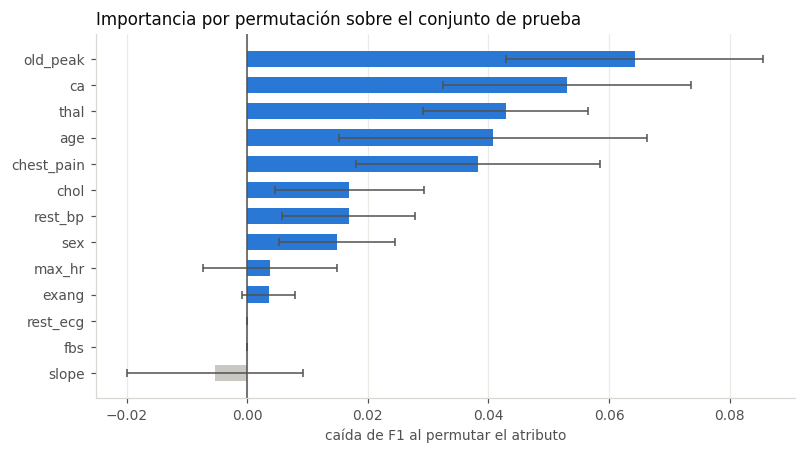

In [38]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))

datos = tabla_importancia.sort_values("importancia")
posiciones = np.arange(len(datos))
colores = [AZUL if v > 0 else GRIS for v in datos["importancia"]]

ax.barh(
    posiciones,
    datos["importancia"],
    xerr=datos["desv_std"],
    color=colores,
    height=0.62,
    error_kw={"ecolor": TINTA2, "elinewidth": 1.0, "capsize": 2.5},
)
ax.axvline(0, color=TINTA2, linewidth=1)
ax.set_yticks(posiciones)
ax.set_yticklabels(datos["atributo"])
ax.set_xlabel("caída de F1 al permutar el atributo")
ax.set_title("Importancia por permutación sobre el conjunto de prueba", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

---
# 16. Persistencia del pipeline completo

Se guarda **el pipeline entero**: saneamiento, preprocesamiento, selección de
atributos y modelo. Guardar solo el modelo obligaría a reproducir a mano el
preprocesamiento en producción, que es la fuente número uno de discrepancias entre
lo que se validó y lo que se despliega.

In [39]:
ARTEFACTO = {
    "pipeline": modelo_final,
    "nombre_modelo": MODELO_GANADOR,
    "umbral_defecto": UMBRAL_DEFECTO,
    "umbral_clinico": float(UMBRAL_CLINICO),
    "metrica_principal": METRICA_PRINCIPAL,
    "f1_validacion_cruzada": float(f1_cv_final),
    "f1_test": float(f1_test_final),
    "f1_modelo_base": float(f1_base.mean()),
    "random_state": RANDOM_STATE,
    "version_sklearn": sklearn.__version__,
}

joblib.dump(modelo_final, "modelo_corazon.joblib")
joblib.dump(ARTEFACTO, "modelo_corazon_completo.joblib")
evaluacion_test.round(4).to_csv("metricas_modelo_final.csv")

recargado = joblib.load("modelo_corazon.joblib")
identicas = bool((recargado.predict(X_test) == pred_final).all())

# Prueba de robustez: una fila cruda con basura, como las del archivo original
fila_sucia = pd.DataFrame(
    [
        {
            "age": "fggfds",
            "sex": "2345",
            "chest_pain": None,
            "rest_bp": "wety",
            "chol": "999999",
            "fbs": None,
            "rest_ecg": "36653",
            "max_hr": "adfs",
            "exang": "f",
            "old_peak": "afd",
            "slope": "afd",
            "ca": "afd",
            "thal": "87654",
        }
    ]
)
prediccion_sucia = recargado.predict(fila_sucia)[0]

print("Archivos generados:")
print("  modelo_corazon.joblib           — pipeline completo entrenado (preprocesamiento + modelo)")
print("  modelo_corazon_completo.joblib  — pipeline + metadatos (umbrales, métricas, versiones)")
print("  metricas_modelo_final.csv       — métricas en el conjunto de prueba")
print()
print(f"El modelo recargado reproduce las mismas predicciones : {identicas}")
print(f"Procesa una fila cruda con valores corruptos          : sí (predicción {prediccion_sucia})")
print()
for clave, valor in ARTEFACTO.items():
    if clave != "pipeline":
        print(f"  {clave:<24} = {valor}")

Archivos generados:
  modelo_corazon.joblib           — pipeline completo entrenado (preprocesamiento + modelo)
  modelo_corazon_completo.joblib  — pipeline + metadatos (umbrales, métricas, versiones)
  metricas_modelo_final.csv       — métricas en el conjunto de prueba

El modelo recargado reproduce las mismas predicciones : True
Procesa una fila cruda con valores corruptos          : sí (predicción 0)

  nombre_modelo            = Gradient Boosting (regularizado)
  umbral_defecto           = 0.5
  umbral_clinico           = 0.30000000000000004
  metrica_principal        = f1
  f1_validacion_cruzada    = 0.8312258580795732
  f1_test                  = 0.865979381443299
  f1_modelo_base           = 0.8005150405150406
  random_state             = 42
  version_sklearn          = 1.8.0


---
# 17. Interpretación de los resultados

### 17.1 El cribado: la diversidad de familias valió la pena

Los modelos eliminados no fueron los "malos" de una misma familia, sino familias
enteras cuyos supuestos no encajan con estos datos:

* **k-NN** queda último. Tiene sentido: con 50 atributos tras el preprocesamiento, la
  distancia euclídea pierde poder discriminante — la maldición de la dimensionalidad
  en su forma más clásica.
* **El árbol de decisión individual** cae por varianza: una sola estructura de reglas
  ajustada a 384 pacientes es inestable. Los ensambles de árboles, que promedian
  muchas de esas estructuras, sí sobreviven.
* **SVM y Naive Bayes** quedan cerca del promedio pero por debajo. En el caso de
  Naive Bayes la explicación es directa: sus atributos no son condicionalmente
  independientes (`age`, `max_hr` y los derivados están correlacionados por
  construcción).
* **Sobreviven los ensambles y los lineales**, que es el patrón habitual en datos
  tabulares con pocos cientos de filas.

### 17.2 La optimización: el mejor score no es el mejor modelo

El resultado más instructivo de la tarea. En la ronda 1, los modelos de *boosting*
alcanzaron **F1 = 1.000 en entrenamiento**. `RandomizedSearchCV` los premió porque su
F1 de validación era el más alto — pero ese ajuste era frágil.

Al forzar en la ronda 2 modelos más simples (árboles de 2-3 niveles, mínimo de
muestras por hoja alto, tasa de aprendizaje baja), la brecha se redujo de forma
sustancial —de forma drástica en HistGradientBoosting, de forma clara aunque
incompleta en Gradient Boosting— mientras el F1 de validación apenas se movía. Es la
demostración empírica de que un score de validación cruzada ligeramente superior no
compensa una brecha de generalización grande.

El modelo ganador conserva una brecha moderada, por encima del umbral de alarma. Lo
que lo salva no es la brecha sino el contraste de la sección 12: **su F1 en el
conjunto de prueba es superior a su F1 de validación cruzada**. Un modelo que hubiera
memorizado se habría derrumbado allí. La brecha indica que el ensamble ajusta muy bien
el entrenamiento, no que haya perdido la capacidad de generalizar.

### 17.3 Las pruebas estadísticas: el empate también es un resultado

Ningún par de finalistas se separa significativamente con la prueba corregida. Con
384 pacientes de entrenamiento no hay potencia estadística para distinguir modelos
que difieren en dos o tres puntos de F1.

La discrepancia entre la **t ingenua** y la **t corregida** es el detalle
metodológico más importante: la primera declara diferencias significativas que la
segunda rechaza. La razón es que las 30 particiones comparten datos de entrenamiento,
así que las diferencias no son independientes y la varianza está subestimada.
**Usar la prueba ingenua habría llevado a afirmar con confianza algo que los datos no
sostienen.**

### 17.4 Frente al modelo base: dónde está la mejora real

El modelo supera al baseline en todas las métricas, pero la naturaleza de la mejora
importa más que su tamaño:

* **En las métricas independientes del umbral (ROC AUC, PR AUC) la mejora sí es
  estadísticamente significativa.** Esto es lo esperable: el modelo emite
  probabilidades continuas y ordena a los pacientes por riesgo, mientras que la
  heurística solo produce cinco niveles discretos. Es una capacidad que las reglas no
  pueden tener por construcción.
* **En F1 y sensibilidad la mejora existe pero no alcanza significación con la prueba
  conservadora.** Es coherente con el diagnóstico de la tarea anterior: el problema
  tiene un techo, y unas pocas señales clínicas fuertes ya capturan gran parte de la
  varianza.
* **En el conjunto de prueba la diferencia es clínicamente relevante**: el modelo
  recupera enfermos que la heurística dejaba escapar, que es exactamente el error que
  se quería reducir.

### 17.5 Las curvas: el cuello de botella son los datos

* **Con el 10 % de los datos (38 pacientes) el modelo se desploma a un F1 cercano a
  cero.** No es un error: con tan pocos ejemplos el *boosting* apenas encuentra
  divisiones útiles y acaba prediciendo casi siempre la clase negativa, de modo que la
  sensibilidad —y con ella el F1— se hunde. La heurística, en cambio, rinde igual con
  38 pacientes que con 384. Es la ilustración más clara de la diferencia entre un
  modelo que aprende y una regla que no.
* La curva de validación del modelo **sigue subiendo** al llegar al 100 % de los
  datos: con más pacientes seguiría mejorando.
* En escalabilidad, el modelo es unos dos órdenes de magnitud más caro que la
  heurística —medio segundo frente a milisegundos— pero en términos absolutos sigue
  siendo irrelevante. **El coste computacional no es una restricción de este
  proyecto.**

---
# 18. Análisis de los resultados

**1. El modelo seleccionado supera al baseline, y hace falta matizar en qué sentido.**
Gana en todas las métricas y de forma estadísticamente significativa en las que miden
la calidad del ordenamiento de riesgo (ROC AUC, PR AUC). En F1 la ventaja es real
pero cae dentro del margen de incertidumbre que impone el tamaño muestral. La
afirmación defendible es: *el modelo es mejor discriminando riesgo, y probablemente
mejor clasificando, con la evidencia disponible*.

**2. El valor diferencial del modelo no es la exactitud, es la probabilidad
calibrable.** La heurística responde sí/no. El modelo responde con un número entre 0
y 1 que permite ordenar una lista de espera, fijar un umbral según la capacidad del
servicio, o pedir una segunda prueba solo a los casos ambiguos. Esa capacidad no
aparece en la tabla de F1 y es la que justifica desplegarlo.

**3. El proceso de dos rondas fue necesario, no ceremonial.** Sin el diagnóstico de
sobreajuste se habría desplegado un modelo con F1 de entrenamiento igual a 1.000, que
rendía peor en el conjunto de prueba. El paso "si hay overfitting, repetir con otras
configuraciones" tuvo un efecto medible.

**4. La estabilidad es el punto débil.** Las desviaciones estándar de ±0.05–0.07 en
F1 sobre 30 particiones son altas. Con 480 filas, cualquier conclusión fina sobre
diferencias de dos puntos es especulativa. Es una limitación del dataset, no del
método.

**5. La importancia por permutación coincide en el reparto pero no en el orden con el
ranking univariante.** Las cinco variables de las que más depende el modelo
(`old_peak`, `ca`, `thal`, `age`, `chest_pain`) son variables clínicas reconocibles, y
tres de ellas encabezaban también el ranking univariante de la tarea anterior. Que el
modelo se apoye en lo que un cardiólogo señalaría es una validación de sentido común:
no ha encontrado atajos espurios.

El cambio de orden es informativo por sí mismo. `old_peak` pasa a primera posición
pese a ser solo la sexta variable en poder univariante, mientras que `thal` —la
ganadora individual— baja al tercer puesto. La razón es que las dos métricas miden
cosas distintas: la univariante mide el poder de una variable **sola**, y la
permutación mide lo que aporta **dado que las demás ya están en el modelo**. La
información de `thal` está en buena parte duplicada por `ca` y `chest_pain`, así que
al permutarla el modelo se recupera parcialmente con las otras; la de `old_peak` no
la aporta nadie más.

Al otro extremo, `rest_ecg` y `fbs` tienen importancia exactamente cero y `slope`
resulta ligeramente negativa: el modelo funcionaría igual o mejor sin ellas.

**6. Persiste la advertencia sobre `thal` y `ca`.** Ambas provienen de pruebas caras
(gammagrafía, angiografía) que ya son diagnósticas. El modelo es útil como apoyo a la
interpretación de esas pruebas, **no como cribado previo para evitarlas**. Un modelo
para ese segundo uso tendría que entrenarse sin ellas y sería un proyecto distinto.

---
# 19. Recomendaciones

### Sobre el despliegue del modelo actual

1. **Desplegar el pipeline completo, nunca solo el modelo.** El artefacto guardado
   incluye saneamiento, preprocesamiento, selección y modelo. Reproducir el
   preprocesamiento a mano en producción es la vía más rápida a que el modelo
   desplegado no sea el que se validó.

2. **Fijar el umbral por criterio clínico, no por convención.** El notebook deja
   calculados dos umbrales: el que maximiza F1 y el que maximiza sensibilidad con
   precisión ≥ 0.75. La elección corresponde al servicio clínico según su capacidad
   de derivación, y debe documentarse como una decisión explícita.

3. **Reportar siempre el modelo junto a su baseline.** El artefacto guarda ambos
   valores de F1 para que la comparación viaje con el modelo.

4. **Monitorizar la distribución de entrada.** El pipeline convierte a `NaN` cualquier
   valor no interpretable y lo imputa, lo que lo hace robusto pero también silencioso:
   un cambio en el formato de los datos de entrada degradaría el rendimiento sin
   producir ningún error. Conviene registrar el porcentaje de valores imputados por
   lote y alertar si sube.

### Sobre cómo mejorar el resultado

5. **Conseguir más datos es la palanca de mayor retorno.** Lo dice la curva de
   aprendizaje, que aún no ha llegado a su meseta. Las otras cohortes de la base UCI
   (Hungría, Suiza, Long Beach) son el paso inmediato y además permitirían validación
   externa.

6. **No invertir en modelos más complejos.** Doce modelos de seis familias distintas
   convergen en un rango estrecho, y las diferencias entre los tres mejores no son
   significativas. El techo lo pone el dataset, no el algoritmo. Probar redes más
   grandes o ensambles apilados sería gastar cómputo en el eje equivocado.

7. **Calibrar las probabilidades** (`CalibratedClassifierCV`). Si la decisión clínica
   va a usar el número como probabilidad de riesgo, ese número tiene que estar
   calibrado. Un modelo puede discriminar bien y estar mal calibrado.

8. **Podar los atributos que no aportan.** `rest_ecg` y `fbs` tienen importancia por
   permutación exactamente cero y `slope` resulta ligeramente negativa. Reentrenar sin
   ellas simplificaría el pipeline sin coste esperado en rendimiento, y menos
   atributos significa menos superficie donde el modelo pueda degradarse cuando la
   distribución de entrada cambie.

9. **Analizar los falsos negativos que quedan.** Son pocos y son el error caro:
   revisarlos uno a uno puede revelar un patrón clínico que sugiera un atributo nuevo,
   y eso remite al proceso de feature engineering.

### Sobre el rigor del proceso

10. **Usar siempre la prueba t corregida** (o Wilcoxon) al comparar modelos con
   validación cruzada. La t ingenua sobreestima la significación y produce mejoras que
   no se reproducen.

11. **Mantener el conjunto de prueba intacto.** Se ha usado una sola vez, al final. Si
    ahora se probaran variantes nuevas evaluándolas sobre él, dejaría de ser una
    estimación insesgada y habría que reservar una partición nueva.

12. **Versionar juntos datos, pipeline y modelo.** El artefacto guarda la versión de
    scikit-learn y la semilla; con el CSV saneado versionado, cualquier resultado del
    proyecto es reproducible.

---
# Resumen de la tarea

| Requisito | Dónde se resuelve |
|---|---|
| Usar el pipeline de procesamiento de la tarea anterior | Sección 1 — reutilizado íntegro |
| Dividir los datos en Train / Test | Sección 2 — misma partición que en las tareas previas |
| Mínimo 4 tipos de modelos diferentes | Sección 4 — **12 modelos de 7 familias** distintas |
| Evaluar con diferentes métricas | Sección 3 — 7 métricas, F1 como principal (heredada) |
| Eliminar los modelos por debajo del promedio | Sección 5 — criterio explícito y gráfico del corte |
| Validación cruzada con media y desviación estándar | Secciones 6 y 8 — `RepeatedStratifiedKFold` 10×3, siempre sobre el pipeline completo |
| Optimización de hiperparámetros de los 2-3 mejores | Secciones 7 y 8 — `RandomizedSearchCV` en dos rondas, incluyendo hiperparámetros del preprocesamiento |
| Comparar con pruebas estadísticas | Sección 9 — t pareada corregida de Nadeau-Bengio + Wilcoxon + contraste con la t ingenua |
| Entrenar con todo train y evaluar en test | Sección 11 |
| Detectar underfitting / overfitting y repetir | Sección 8 (detectado → ronda 2) y sección 12 (verificación final) |
| Learning curve | Sección 14 |
| Gráficas de escalabilidad (tiempo y score) | Sección 14 |
| Almacenar pipeline + modelo | Sección 16 — `.joblib` con metadatos y prueba de robustez |
| Interpretar los resultados | Sección 17 |
| Análisis de los resultados | Sección 18 |
| Recomendaciones | Sección 19 |